# Section 5: RQ3 — DBS Classification & Cross-Condition

| # | Figure | Count |
|---|--------|-------|
| 49 | Classification BA dot plot (prediction + forecast, 2×2: PSID/DPAD × z-as-behavior/z-as-neural) | 1 |
| 49a | Confusion matrix grids (4 separate figures: PSID/DPAD × behavioral/laplacian) | 4 |
| 51 | Cross-condition (flipped) forecast classification dot plot (PSID only, 1×2) | 1 |

**Archived** (results non-significant — see `thesis_figures/sec5/archive/`):
fig_050 ROC prediction, fig_050b ROC forecast, fig_052 prediction onset (t_cut), fig_052b forecast horizon decay.

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

from pathlib import Path
import csv
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from sklearn.metrics import confusion_matrix as sk_confusion_matrix

from modules.style import (
    COLOR_DPAD,
    COLOR_PSID,
    apply_thesis_style,
    panel_label,
)
from modules.loaders import SESSIONS, pretty_exp
from modules.sec2_common import SESSION_COLORS

apply_thesis_style()

OUT = Path("thesis_figures/sec5")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()

## Classification spec lists

In [2]:
GROUP_ORDER: Tuple[str, ...] = ("xp", "xp_1", "xp_2", "xp_with_dbs")
GROUP_SHORT: Dict[str, str] = {
    "xp": "Xp",
    "xp_1": "Xp1",
    "xp_2": "Xp2",
    "xp_with_dbs": "Xp+DBS",
}
GROUP_COLORS: Dict[str, str] = {
    "xp": COLOR_PSID,
    "xp_1": "#0F6E56",
    "xp_2": "#993C1D",
    "xp_with_dbs": "#854F0B",
}

_ORDERED_SESSION_KEYS: List[str] = [
    "PDI1_S2",
    "PDI1_S4",
    "PDI4_S2",
    "PDI4_S3",
    "PDI1_S2 (lap)",
    "PDI1_S4 (lap)",
    "PDI4_S2 (lap)",
    "PDI4_S3 (lap)",
]

In [3]:
@dataclass(frozen=True)
class ClassificationF1Point:
    participant_label: str
    session_label: str
    group: str
    balanced_accuracy: float  # cv_ba — the statistic the permutation test tests
    permutation_pvalue: Optional[float]
    model_label: str = "PSID"
    permutation_scores: Optional[Tuple[float, ...]] = None
    perm_mean_ba: Optional[float] = None
    # Transfer BA at `score_config`; reported for context, never permutation-tested.
    ba_at_score: Optional[float] = None
    score_config: Optional[str] = None

In [4]:
# Parquet loaders

_PRED_SRC_TO_GROUP: Dict[str, str] = {
    "Xp": "xp",
    "Xp_1": "xp_1",
    "Xp_2": "xp_2",
    "Xp_with_dbs": "xp_with_dbs",
}
_FCST_SRC_TO_GROUP: Dict[str, str] = {
    "Xf": "xp",
    "Xf_1": "xp_1",
    "Xf_2": "xp_2",
    "Xf_with_dbs": "xp_with_dbs",
}

In [5]:
# Reported forecast config (h=5 s history, m=2 s forecast).
_FIXED_H, _FIXED_M = 5.0, 2.0

# Latent-only feature sources (the Xp+DBS control is excluded — it is a leaked-label
# ceiling check, not a testable condition).
_LATENT_SRC = ("Xp", "Xp_1", "Xp_2", "Xf", "Xf_1", "Xf_2")


def _load_sweep_df(results_root: Path) -> pd.DataFrame:
    files = glob.glob(
        str(results_root / "psid" / "*" / "classification" / "sweep_*.parquet")
    ) + glob.glob(
        str(results_root / "dpad" / "*" / "classification" / "sweep_*.parquet")
    )
    if not files:
        return pd.DataFrame()
    # Recency comes from the sweep file's own name (`sweep_YYYYMMDD_HHMMSS.parquet`),
    # NOT from the `run_ts` column. Six PSID variants have two sweep files, a June 14 and
    # a June 15 re-run, and both carry the SAME stale `run_ts` copied from the original
    # May 11 fit. Sorting on `run_ts` therefore cannot tell them apart, and `keep="last"`
    # silently mixed rows from the two: the June 14 file has NaN `p_value` for conditions
    # the June 15 re-run actually tested. Sort on the file stamp so the later re-run wins.
    files = sorted(files, key=lambda f: (Path(f).stem, f))
    df = pd.concat(
        [pd.read_parquet(f).assign(_file_stamp=Path(f).stem) for f in files],
        ignore_index=True,
    )
    # Collapse reruns only — every sweep grid axis stays in the key. `predictions` rows
    # vary in t_cut_seconds (h/m are None, sweep.py:431-433); `forecast` rows vary in
    # (h_seconds, m_test_seconds) (t_cut is None, :602-604). Dropping any of the three
    # collapses that grid to one arbitrary row per cell.
    # Deterministic tie-break: `run_ts` has exact ties across re-runs and pandas'
    # default quicksort is not stable, so `keep="last"` otherwise picks a different row
    # between runs and the tested/gated census wobbles by a few conditions.
    return df.sort_values(
        ["_file_stamp", "run_ts"], kind="mergesort"
    ).drop_duplicates(
        subset=[
            "variant", "sub_source", "flipped", "mode",
            "t_cut_seconds", "h_seconds", "m_test_seconds",
        ],
        keep="last",
    )


def _collapse_grid(df: pd.DataFrame) -> pd.DataFrame:
    """One row per (variant, sub_source, flipped, mode): the reported point on the grid.

    Only `ba_at_score` moves along the grid. `cv_ba`, `p_value` and `perm_scores` are
    computed once per fit and broadcast to every row (`sweep.py:293-322`), so this choice
    cannot affect the plotted statistic or the test — it selects the *context* number.

    `predictions`: the largest `t_cut_seconds` (least-trimmed window, closest to the
    window the LDA was fit on). `forecast`: the reported h=5 s / m=2 s config.
    """
    if df.empty:
        return df
    key = ["variant", "sub_source", "flipped", "mode"]
    is_pred = df["mode"] == "predictions"
    pred = df[is_pred].sort_values(["t_cut_seconds", "run_ts"])
    fcst = df[~is_pred]
    if not fcst.empty:
        at_fixed = (fcst["h_seconds"] == _FIXED_H) & (fcst["m_test_seconds"] == _FIXED_M)
        fcst = (
            fcst.assign(_at_fixed=at_fixed.fillna(False))
            .sort_values(["_at_fixed", "m_test_seconds", "run_ts"])
            .drop(columns="_at_fixed")
        )
    return pd.concat([pred, fcst]).drop_duplicates(subset=key, keep="last")


def _score_config(row) -> str:
    """Human-readable label for the grid point `ba_at_score` was measured at."""
    if row["mode"] == "predictions":
        return f"t_cut={row['t_cut_seconds']:g}"
    return f"h{row['h_seconds']:g}_m{row['m_test_seconds']:g}"

In [6]:
def _parse_variant_meta(
    variant: str,
) -> Tuple[Optional[str], Optional[str], Optional[str], Optional[int]]:
    """Returns (exp_type, participant, session, n1) or (None, None, None, None)."""
    m = re.search(r"z-as-(behavior|neural)_(PDI\d+)_(S\d+).*?_n1_(\d+)", variant)
    if not m:
        return None, None, None, None
    exp_type = "behavioral" if m.group(1) == "behavior" else "laplacian"
    return exp_type, m.group(2), m.group(3), int(m.group(4))

In [7]:
_sweep_df = _load_sweep_df(results_root)

/tmp/ipykernel_1673195/2544692767.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


In [8]:
def build_cls_points_from_parquet(
    mode: str = "predictions",
    flipped: bool = False,
    dbs_filter: str = "both",
    pipeline: str = "psid",
) -> List[ClassificationF1Point]:
    """One ClassificationF1Point per (session, feature group) from sweep parquets.

    `balanced_accuracy` carries `cv_ba` — the statistic `_permutation_pvalue` compares
    against the null (`sweep.py:200`) and the statistic each null draw reproduces
    (`_one_permutation` returns the mean of the same chrono-CV fold BAs). `ba_at_score`
    is kept alongside for context but is never the tested quantity.
    """
    src_map = _PRED_SRC_TO_GROUP if mode == "predictions" else _FCST_SRC_TO_GROUP
    if _sweep_df.empty:
        return []
    df = _sweep_df[
        (_sweep_df["mode"] == mode)
        & (_sweep_df["flipped"] == flipped)
        & (_sweep_df["sub_source"].isin(src_map.keys()))
        & (_sweep_df["variant"].str.contains(f"_dbs_{dbs_filter}$"))
        & (_sweep_df["pipeline"] == pipeline)
    ]
    # One cell per feature set — `_sweep_df` keeps the full t_cut / (h, m) grid.
    df = _collapse_grid(df)
    points: List[ClassificationF1Point] = []
    for _, row in df.iterrows():
        exp_type, participant, session, _ = _parse_variant_meta(row["variant"])
        if participant is None:
            continue
        group = src_map[row["sub_source"]]
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        pval = float(row["p_value"]) if pd.notna(row["p_value"]) else None
        pmean = row.get("perm_mean_ba")
        pmean = float(pmean) if pd.notna(pmean) else None
        raw_scores = row.get("perm_scores")
        pscores = (
            tuple(float(v) for v in raw_scores)
            if raw_scores is not None and hasattr(raw_scores, "__len__") and len(raw_scores) > 0
            else None
        )
        points.append(
            ClassificationF1Point(
                participant_label=participant,
                session_label=sess_label,
                group=group,
                balanced_accuracy=float(row["cv_ba"]),
                permutation_pvalue=pval,
                model_label=("PSID" if pipeline == "psid" else "DPAD"),
                permutation_scores=pscores,
                perm_mean_ba=pmean,
                ba_at_score=float(row["ba_at_score"]),
                score_config=_score_config(row),
            )
        )
    return points

In [9]:
def build_forecast_bests_from_parquet(pipeline: str = "psid") -> (
    Dict[Tuple[str, str], Tuple[float, Optional[str], Optional[float], Optional[Tuple[float, ...]], float]]
):
    """Forecast classification per (session_key, feature_group) at the reported config.

    Returns (cv_ba, h_m, p_value, perm_scores, ba_at_score). `cv_ba` is the plotted and
    tested statistic; it varies with `h_seconds` (one LDA fit per h) but not with
    `m_test_seconds`, so the h=5 filter selects the fit and the m=2 filter only fixes
    which transfer score `ba_at_score` reports.
    """
    if _sweep_df.empty:
        return {}
    df = _sweep_df[
        (_sweep_df["mode"] == "forecast")
        & (_sweep_df["flipped"] == False)
        & (_sweep_df["sub_source"].isin(_FCST_SRC_TO_GROUP.keys()))
        & (_sweep_df["variant"].str.contains("_dbs_both$"))
        & (_sweep_df["pipeline"] == pipeline)
        & (_sweep_df["h_seconds"] == _FIXED_H)
        & (_sweep_df["m_test_seconds"] == _FIXED_M)
    ]
    # Fixed forecast config (h=5 s history, m=2 s forecast); not swept for the best horizon.
    best = df.drop_duplicates(subset=["variant", "sub_source"])
    out: Dict[Tuple[str, str], Tuple[float, Optional[str], Optional[float], Optional[Tuple[float, ...]], float]] = {}
    for _, row in best.iterrows():
        exp_type, participant, session, _ = _parse_variant_meta(row["variant"])
        if participant is None:
            continue
        group = _FCST_SRC_TO_GROUP[row["sub_source"]]
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        sess_key = f"{participant}_{sess_label}"
        pval = float(row["p_value"]) if pd.notna(row["p_value"]) else None
        raw_scores = row.get("perm_scores")
        pscores = (
            tuple(float(v) for v in raw_scores)
            if raw_scores is not None and hasattr(raw_scores, "__len__") and len(raw_scores) > 0
            else None
        )
        h_m = _score_config(row)
        out[(sess_key, group)] = (
            float(row["cv_ba"]), h_m, pval, pscores, float(row["ba_at_score"])
        )
    return out

In [10]:
def _cm_from_sweep(variant: str, sub_source: str, pipe: str) -> Optional[np.ndarray]:
    """2x2 confusion matrix from cv_y_true + cv_y_pred in sweep parquet.

    PSID uses mode='predictions' (Xp sub_sources).
    DPAD uses mode='forecast' (Xf sub_sources — DPAD has no prediction classification phase).
    """
    cls_mode = "predictions" if pipe == "psid" else "forecast"
    rows = _sweep_df[
        (_sweep_df["variant"] == variant)
        & (_sweep_df["sub_source"] == sub_source)
        & (_sweep_df["pipeline"] == pipe)
        & (_sweep_df["mode"] == cls_mode)
        & (_sweep_df["flipped"] == False)
    ]
    if rows.empty:
        return None
    # `cv_y_true` / `cv_y_pred` come from the single CV fit and are identical across the
    # grid; collapse anyway so the pick is deterministic.
    r = _collapse_grid(rows).iloc[0]
    y_true = np.asarray(r["cv_y_true"])
    y_pred = np.asarray(r["cv_y_pred"])
    if len(y_true) == 0:
        return None
    return sk_confusion_matrix(y_true, y_pred, labels=[0, 1])

In [11]:
print(
    f"Sweep parquet: {len(_sweep_df)} rows, {_sweep_df['variant'].nunique()} variants."
)
print(f"Ordered session keys: {_ORDERED_SESSION_KEYS}")

Sweep parquet: 6368 rows, 32 variants.
Ordered session keys: ['PDI1_S2', 'PDI1_S4', 'PDI4_S2', 'PDI4_S3', 'PDI1_S2 (lap)', 'PDI1_S4 (lap)', 'PDI4_S2 (lap)', 'PDI4_S3 (lap)']


## Fig 49: Classification — prediction vs forecast (2×2 dot plot)

PSID and DPAD shown. Rows: z-as-behavior (top), z-as-neural (bottom). Cols: PSID (left), DPAD (right).

x-axis: feature group (Xp | Xp1 | Xp2). Dots colored by session. Circle = prediction; triangle = forecast (h=5 s).

**Plotted statistic is `cv_ba`, not `ba_at_score`.** The LDA is fit once per (variant, feature source, mode, h) and `_permutation_pvalue` compares that fit's cross-validated balanced accuracy against the null (`sweep.py:200`); each null draw is the mean of the same chrono-CV fold BAs (`_one_permutation`). `ba_at_score` is a separate number — the fitted pipeline transferred to a score set built at a different `t_cut` (predictions) or `m_test` (forecast) — and is never compared to the null. Plotting `ba_at_score` beside a `cv_ba` null put the markers and the null on different scales; the appendix CSV and the printout below carry both columns.

**Permutation null:** thin grey box plot of the pooled 500-draw null distribution (sessions pooled per feature group), drawn beside the observed markers. Filled dot with black edge = p < 0.05; faded = n.s. The within-model nulls take only ~9–15 distinct values because 6–8 block labels are permuted, so the boxes render blocky with long whiskers — a property of the design, not of the plot.

**Xp+DBS dropped.** The leaked-label control cannot be permutation-tested coherently: the appended channel is built from the true labels while only `y` is shuffled, so its stored p-value is meaningless. Its balanced accuracy is printed below as a ceiling check and quoted in the text with no p attached.

**DPAD has no `predictions` rows** in the sweep, so every DPAD marker is a forecast triangle and panels B and D contain no circles (verified by the row-count print below).

In [12]:
SHOW_DPAD = True

cls_points_psid = build_cls_points_from_parquet(
    mode="predictions", flipped=False, dbs_filter="both", pipeline="psid"
)
cls_points_dpad = build_cls_points_from_parquet(
    mode="predictions", flipped=False, dbs_filter="both", pipeline="dpad"
)
cls_points = cls_points_psid + (cls_points_dpad if SHOW_DPAD else [])
forecast_bests_psid = build_forecast_bests_from_parquet("psid")
forecast_bests_dpad = build_forecast_bests_from_parquet("dpad") if SHOW_DPAD else {}

In [13]:
def _mode_from_session_label(session_label: str) -> str:
    return "laplacian" if "(lap)" in session_label else "behavioral"

In [14]:
# Pooled buckets keyed by (feature, model, mode).
# Entry layout: (session_key, cv_ba, p_value, perm_scores, ba_at_score, score_config).
# Element 1 is the plotted/tested statistic; element 4 is context only.
pooled_pred: Dict[Tuple[str, str, str], List] = {}
for pt in cls_points:
    sess_key = f"{pt.participant_label}_{pt.session_label}"
    mode = _mode_from_session_label(pt.session_label)
    pooled_pred.setdefault((pt.group, pt.model_label, mode), []).append(
        (sess_key, pt.balanced_accuracy, pt.permutation_pvalue, pt.permutation_scores,
         pt.ba_at_score, pt.score_config)
    )

pooled_fcst: Dict[Tuple[str, str, str], List] = {}
for src, model in [(forecast_bests_psid, "PSID"), (forecast_bests_dpad, "DPAD")]:
    for (sess, grp), (cv_ba, hm, pval, pscores, ba_score) in src.items():
        mode = _mode_from_session_label(sess)
        pooled_fcst.setdefault((grp, model, mode), []).append(
            (sess, cv_ba, pval, pscores, ba_score, hm)
        )

# Session keys in canonical order.
_all_skeys = {f"{pt.participant_label}_{pt.session_label}" for pt in cls_points}
session_keys = [sk for sk in _ORDERED_SESSION_KEYS if sk in _all_skeys]

features = list(GROUP_ORDER)

# Fig 49 drops the Xp+DBS control: it cannot be permutation-tested coherently — the
# appended channel is built from the true labels while only y is shuffled — so plotting a
# marker beside a null band would misrepresent it. Its balanced accuracy is printed as a
# ceiling check below instead. The confusion-matrix grids still use all four feature sets.
cls_features = [f for f in features if f != "xp_with_dbs"]

In [15]:
def _draw_null_box(ax, pos, draws):
    """Permutation-null draws as a thin grey box plot, drawn behind the BA markers.

    The draws are chrono-CV balanced accuracies (`_one_permutation` returns the mean of
    the fold BAs), i.e. the same scale as the plotted `cv_ba`.
    """
    if not draws:
        return
    bp = ax.boxplot(
        [draws], positions=[pos], widths=0.16, showfliers=False,
        patch_artist=True, manage_ticks=False, zorder=1,
    )
    for patch in bp["boxes"]:
        patch.set(facecolor="#EEEEEE", edgecolor="#AAAAAA", linewidth=0.6)
    for key in ("whiskers", "caps", "medians"):
        for ln in bp[key]:
            ln.set(color="#AAAAAA", linewidth=0.6)


def _draw_cls_panel(ax, exp_mode, model_label):
    """Per feature set: session cv_ba markers (circle=prediction, triangle=forecast) with
    a thin grey box plot of the pooled permutation-null draws alongside them.

    Markers and null are both on the cross-validated balanced-accuracy scale, which is
    what the p-value tests.
    """

    def _rank(e):
        base = e[0].replace(" (lap)", "")
        try:
            return list(SESSIONS).index(base)
        except ValueError:
            return 99

    def _slots(n, lo, hi):
        if n <= 0:
            return np.array([])
        if n == 1:
            return np.array([(lo + hi) / 2.0])
        return np.linspace(lo, hi, n)

    def _draw_markers(entries, lo, hi, marker):
        xs = _slots(len(entries), lo, hi)
        for j, entry in enumerate(entries):
            sess_key, cv_ba, pval = entry[0], entry[1], entry[2]
            if not np.isfinite(cv_ba):
                continue
            sess_color = SESSION_COLORS.get(sess_key.replace(" (lap)", ""), "#888888")
            sig = pval is not None and pval < 0.05
            ax.scatter(
                xs[j], cv_ba, s=30, color=sess_color, marker=marker,
                alpha=1.0 if sig else 0.55,
                edgecolor="black" if sig else "none",
                linewidths=0.6, zorder=3,
            )

    for fi, feat in enumerate(cls_features):
        # Pooled permutation null (all 500 draws per tested session, not percentiles).
        all_pscores = []
        for entry in pooled_pred.get((feat, model_label, exp_mode), []):
            if entry[3] is not None:
                all_pscores.extend(entry[3])
        for entry in pooled_fcst.get((feat, model_label, exp_mode), []):
            if entry[3] is not None:
                all_pscores.extend(entry[3])
        _draw_null_box(ax, fi + 0.30, all_pscores)

        pred_entries = sorted(pooled_pred.get((feat, model_label, exp_mode), []), key=_rank)
        _draw_markers(pred_entries, fi - 0.20, fi - 0.06, "o")

        fcst_entries = sorted(pooled_fcst.get((feat, model_label, exp_mode), []), key=_rank)
        _draw_markers(fcst_entries, fi + 0.00, fi + 0.14, "^")

    ax.set_ylim(0.3, 1.05)
    ax.set_ylabel("Cross-validated balanced accuracy")
    ax.set_xticks(np.arange(len(cls_features)))
    ax.set_xticklabels([GROUP_SHORT[f] for f in cls_features])
    ax.set_xlim(-0.5, len(cls_features) - 0.5)
    ax.set_xlabel("Feature set")


In [16]:
def render_cls_figure(save_path):
    """2x2 BA summary: rows=z-as-behavior/z-as-neural, cols=PSID/DPAD."""
    exp_modes = ["behavioral", "laplacian"]
    exp_names = ["z-as-behavior", "z-as-neural"]
    exp_disp = {"z-as-behavior": "Tracing kinematics", "z-as-neural": "Laplacian LFP"}
    models = ["PSID", "DPAD"]
    letter_grid = [["A", "B"], ["C", "D"]]

    fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0))
    for ri, (exp_mode, exp_name) in enumerate(zip(exp_modes, exp_names)):
        for ci, model in enumerate(models):
            ax = axes[ri, ci]
            _draw_cls_panel(ax, exp_mode, model)
            panel_label(ax, letter_grid[ri][ci], f"{model}, {exp_disp[exp_name]}")

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="gray", markersize=6, linestyle="none",
                   label="Prediction"),
        plt.Line2D([0], [0], marker="^", color="gray", markersize=6, linestyle="none",
                   label="Forecast"),
        Patch(facecolor="#EEEEEE", edgecolor="#AAAAAA", linewidth=0.6,
              label="Permutation null"),
        Patch(color=SESSION_COLORS["PDI1_S2"], label="PDI1_S2"),
        Patch(color=SESSION_COLORS["PDI1_S4"], label="PDI1_S4"),
        Patch(color=SESSION_COLORS["PDI4_S2"], label="PDI4_S2"),
        Patch(color=SESSION_COLORS["PDI4_S3"], label="PDI4_S3"),
    ]
    axes[1, 1].legend(handles=legend_handles, fontsize=7, loc="lower right", ncol=2)

    fig.tight_layout()
    fig.savefig(str(save_path))
    plt.show()

/tmp/ipykernel_1673195/2435528560.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


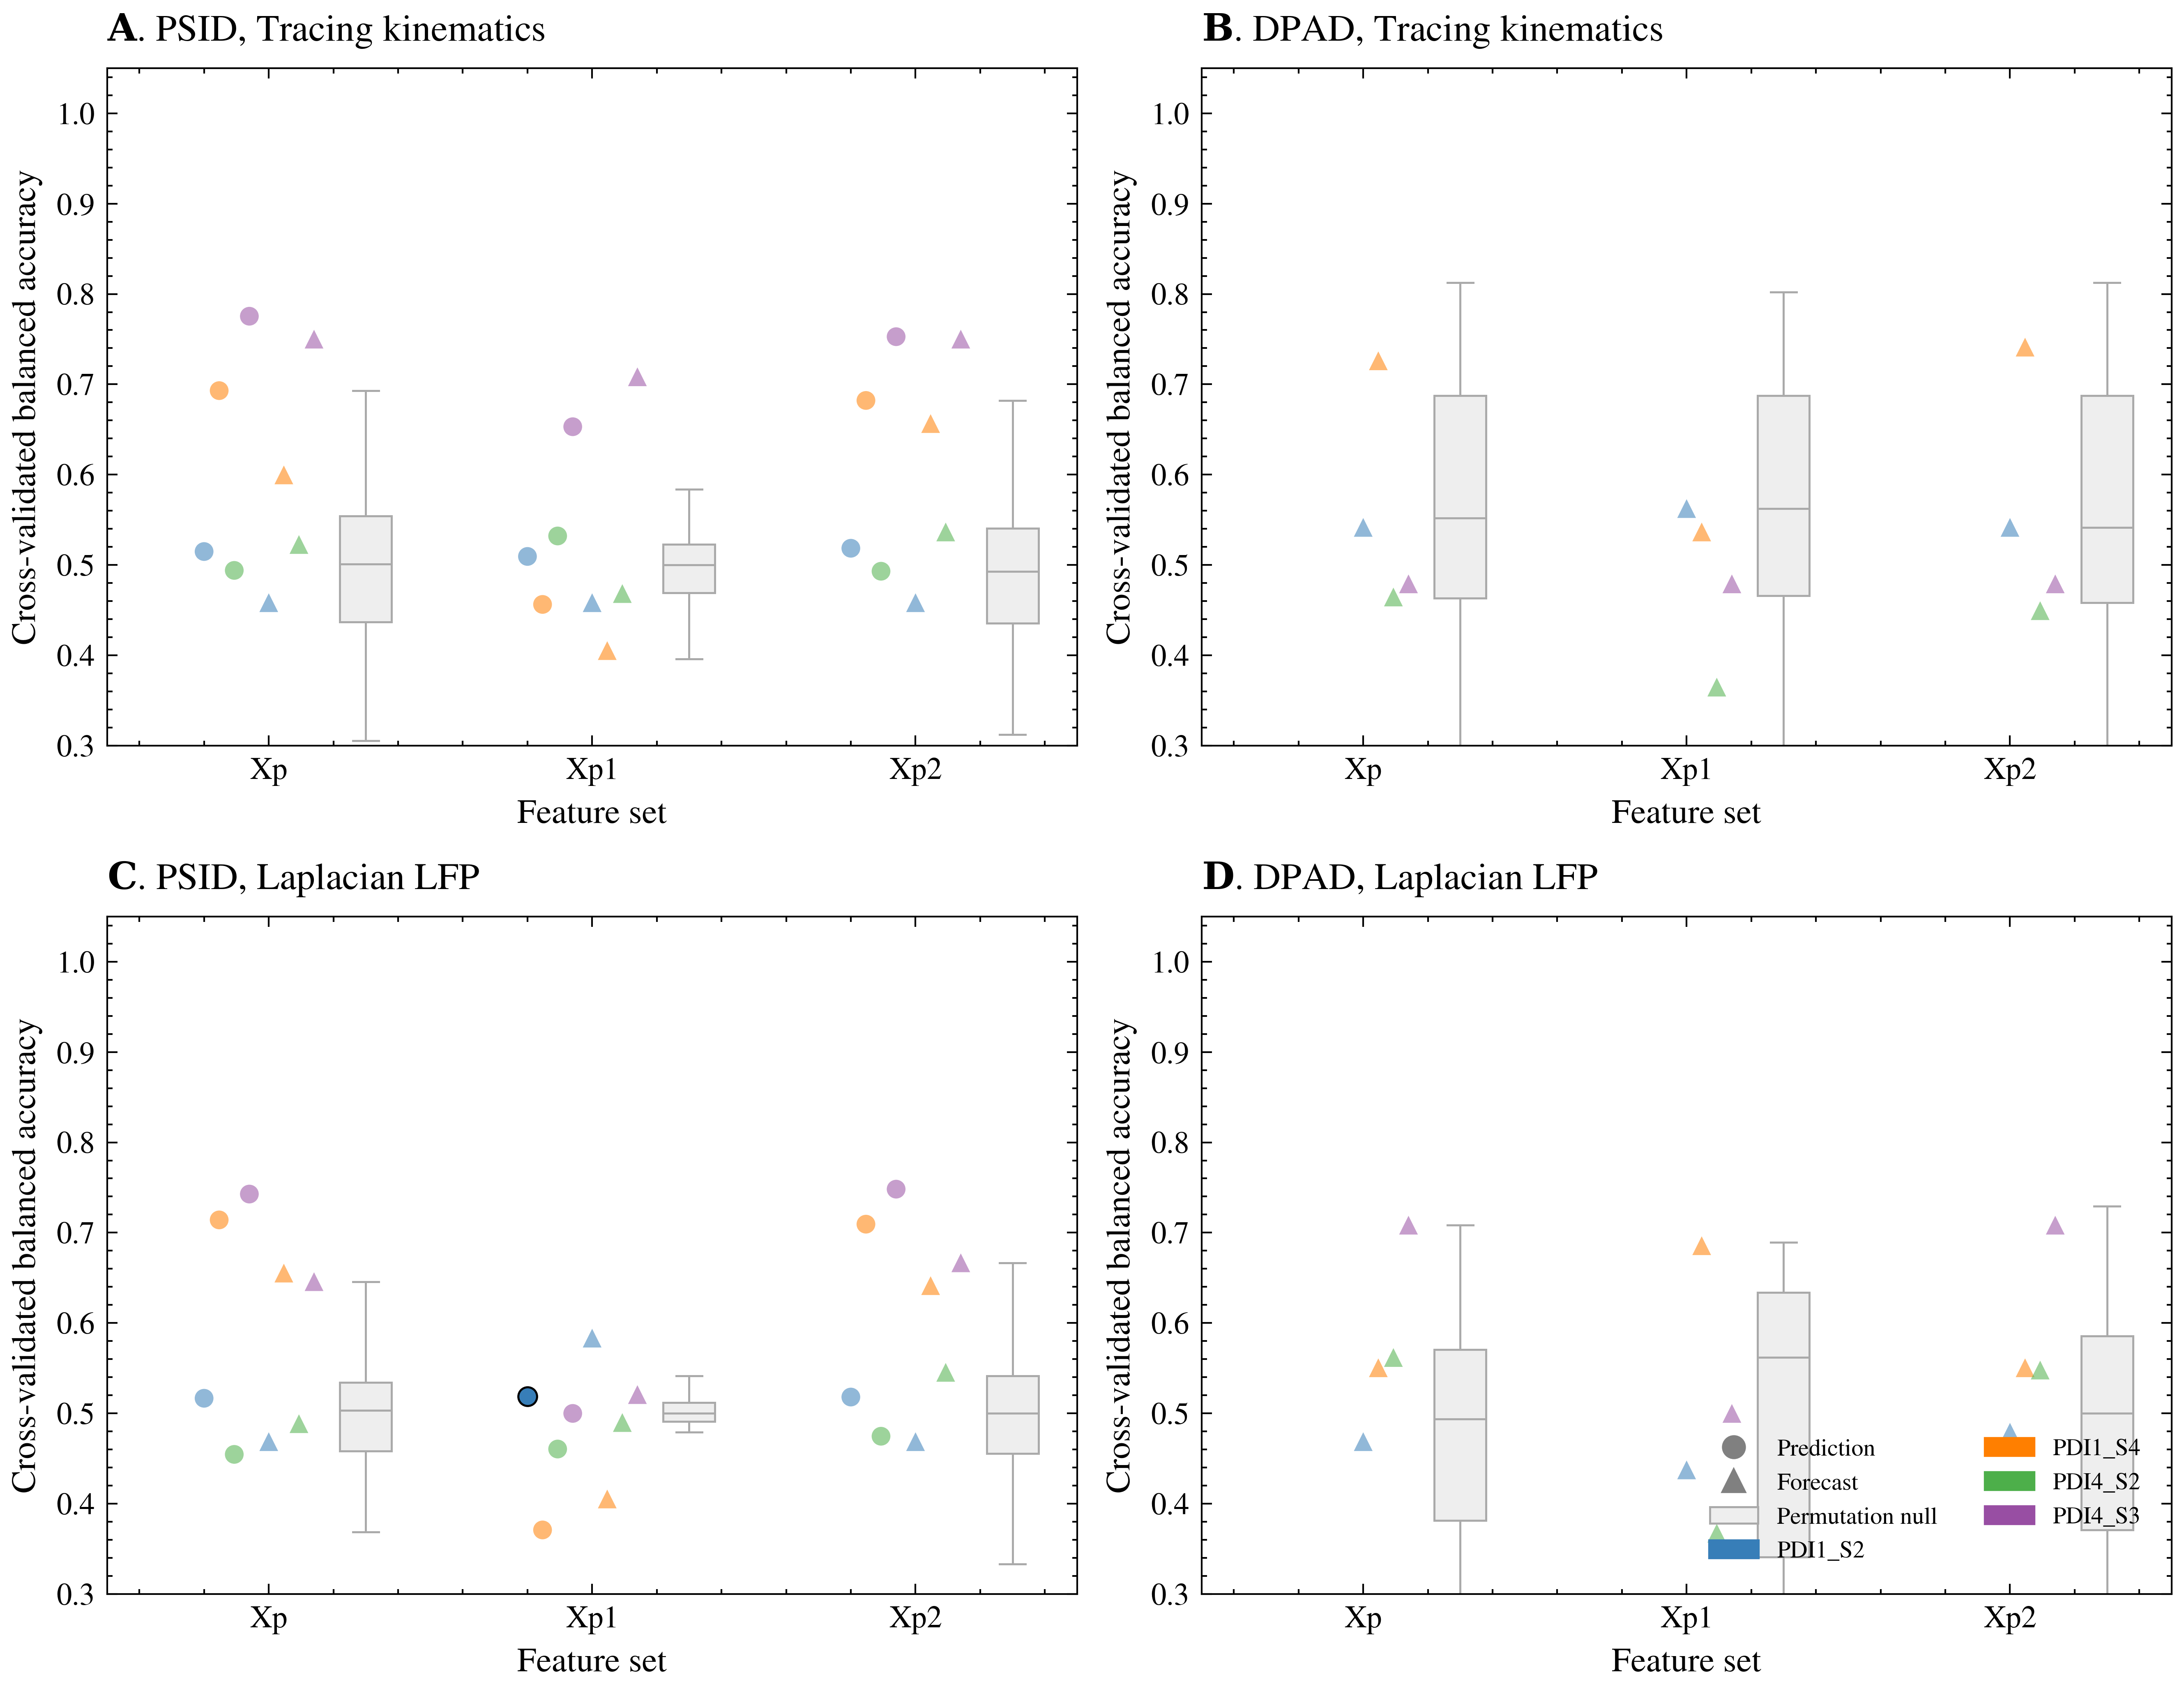

Fig 49 — DBS classification, cross-validated balanced accuracy (cv_ba). 2x2: rows=z-as-behavior/z-as-neural, cols=PSID/DPAD. x-axis: feature group (Xp / Xp1 / Xp2); the Xp+DBS control is reported in text only. Circles=prediction, triangles=forecast (h=5 s). Grey box = pooled permutation null (500 draws per tested session, same cv_ba scale). Filled + black edge = p<0.05; faded = n.s. Latent-only sources non-significant.
CSV: table_049_classification.csv

cv_ba (tested) vs ba_at_score (context) — within-model, _dbs_both:
model mode        target session    feature   cv_ba ba@score   score_config       p
DPAD  forecast    LFP    PDI1_S2    xp        0.469    0.537          h5_m2     -  
DPAD  forecast    LFP    PDI1_S2    xp_1      0.438    0.602          h5_m2     -  
DPAD  forecast    LFP    PDI1_S2    xp_2      0.479    0.535          h5_m2     -  
DPAD  forecast    LFP    PDI1_S2    xp_with_dbs  1.000    1.000          h5_m2   n/a  
DPAD  forecast    LFP    PDI1_S4    xp        0.551 

In [17]:
render_cls_figure(OUT / "fig_049_classification_prediction.png")
print(
    "Fig 49 — DBS classification, cross-validated balanced accuracy (cv_ba). "
    "2x2: rows=z-as-behavior/z-as-neural, cols=PSID/DPAD. "
    "x-axis: feature group (Xp / Xp1 / Xp2); the Xp+DBS control is reported in text only. "
    "Circles=prediction, triangles=forecast (h=5 s). "
    "Grey box = pooled permutation null (500 draws per tested session, same cv_ba scale). "
    "Filled + black edge = p<0.05; faded = n.s. Latent-only sources non-significant."
)

# Appendix CSV.
#  - cv_ba        : the statistic the permutation p-value tests (plotted in Fig 49).
#  - ba_at_score  : transfer BA at `score_config`, never tested; kept for context.
#  - The Xp+DBS control carries no p-value — the appended channel is built from the true
#    labels while the permutation shuffles only y, so its stored p is not a test.
table_path = OUT / "table_049_classification.csv"


def _csv_pvalue(group: str, pval: Optional[float]) -> str:
    if group == "xp_with_dbs" or pval is None:
        return ""
    return f"{pval:.4f}"


def _fmt(v: Optional[float]) -> str:
    return f"{v:.4f}" if v is not None and np.isfinite(v) else ""


with open(table_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "panel", "session", "feature", "model", "mode",
        "cv_ba", "perm_pvalue", "ba_at_score", "score_config",
    ])
    for pt in cls_points:
        sess_key = f"{pt.participant_label}_{pt.session_label}"
        mode = _mode_from_session_label(pt.session_label)
        w.writerow([
            "prediction", sess_key, pt.group, pt.model_label, mode,
            _fmt(pt.balanced_accuracy), _csv_pvalue(pt.group, pt.permutation_pvalue),
            _fmt(pt.ba_at_score), pt.score_config or "",
        ])
    for src_dict, model in [(forecast_bests_psid, "PSID"), (forecast_bests_dpad, "DPAD")]:
        for (sess, grp), (cv_ba, hm, pval, _pscores, ba_score) in src_dict.items():
            mode = _mode_from_session_label(sess)
            w.writerow([
                "forecast", sess, grp, model, mode,
                _fmt(cv_ba), _csv_pvalue(grp, pval), _fmt(ba_score), hm or "",
            ])
print(f"CSV: {table_path.name}")

# cv_ba vs ba_at_score. cv_ba is constant across the whole t_cut / m_test grid and is the
# quantity `_permutation_pvalue` compares against the null; ba_at_score is the LDA
# transferred to a score set built at `score_config` and is never tested. The two can
# differ substantially (e.g. PDI4_S3 kin Xp: cv_ba 0.775 vs ba_at_score 0.75-0.82 across
# t_cut), so the prose must name which one it quotes.
print("\ncv_ba (tested) vs ba_at_score (context) — within-model, _dbs_both:")
print(
    f"{'model':5s} {'mode':11s} {'target':6s} {'session':10s} {'feature':8s} "
    f"{'cv_ba':>6s} {'ba@score':>8s} {'score_config':>14s} {'p':>7s}"
)
_rows_cmp = []
for pt in cls_points:
    _rows_cmp.append((
        pt.model_label, "predictions",
        "LFP" if "(lap)" in pt.session_label else "kin",
        f"{pt.participant_label}_{pt.session_label.replace(' (lap)', '')}",
        pt.group, pt.balanced_accuracy, pt.ba_at_score, pt.score_config,
        pt.permutation_pvalue,
    ))
for src_dict, model in [(forecast_bests_psid, "PSID"), (forecast_bests_dpad, "DPAD")]:
    for (sess, grp), (cv_ba, hm, pval, _ps, ba_score) in src_dict.items():
        _rows_cmp.append((
            model, "forecast",
            "LFP" if "(lap)" in sess else "kin",
            sess.replace(" (lap)", ""),
            grp, cv_ba, ba_score, hm, pval,
        ))
_rows_cmp.sort(key=lambda r: (r[0], r[1], r[2], r[3], r[4]))
for _m, _md, _tgt, _sess, _grp, _cv, _bas, _cfg, _pv in _rows_cmp:
    _ps = "  n/a  " if _grp == "xp_with_dbs" else (
        f"{_pv:.3f}" if _pv is not None else "  -  "
    )
    print(
        f"{_m:5s} {_md:11s} {_tgt:6s} {_sess:10s} {_grp:8s} "
        f"{_cv:6.3f} {_bas:8.3f} {str(_cfg):>14s} {_ps:>7s}"
    )
print(
    "\n'-' = gated out at cv_ba > 0.5, never tested. 'n/a' = leaked-label control, "
    "not testable. cv_ba is constant along the grid axis named in score_config."
)

In [18]:
# Xp+DBS ceiling check — balanced accuracy only, no p-value.
# `_slice_subsource` builds the appended channel from the true y (training/sweep.py:73-75,
# :251) while `_permutation_pvalue` shuffles only y (:311), so under permutation the
# classifier is handed the true label as a feature and scored against a shuffled one. The
# stored p is not a test of anything; the thesis quotes the BA in text instead of plotting it.
_ctrl = _sweep_df[
    (_sweep_df["sub_source"].isin(["Xp_with_dbs", "Xf_with_dbs"]))
    & (_sweep_df["variant"].str.contains("_dbs_both$"))
]
# One row per control cell: largest t_cut for predictions, h=5 s / m=2 s for forecast.
_ctrl = _collapse_grid(_ctrl)

_ctrl_cells = []
for _, _row in _ctrl.iterrows():
    _exp_type, _participant, _session, _ = _parse_variant_meta(_row["variant"])
    if _participant is None:
        continue
    _ctrl_cells.append((
        "PSID" if _row["pipeline"] == "psid" else "DPAD",
        f"{_row['mode']}{' (flip)' if _row['flipped'] else ''}",
        "LFP" if _exp_type == "laplacian" else "kin",
        f"{_participant}_{_session}",
        float(_row["cv_ba"]),
        float(_row["ba_at_score"]),
        _score_config(_row),
    ))
_ctrl_cells.sort()

print("Xp+DBS leaked-label control — balanced accuracy only (no p-value):")
print(
    f"{'model':5s} {'mode':18s} {'target':6s} {'session':10s} "
    f"{'cv_ba':>6s} {'ba@score':>8s} {'score_config':>14s}"
)
for _model, _md, _tgt, _sess, _cv, _ba, _cfg in _ctrl_cells:
    print(f"{_model:5s} {_md:18s} {_tgt:6s} {_sess:10s} {_cv:6.3f} {_ba:8.3f} {_cfg:>14s}")

# The thesis quotes the ceiling on ba_at_score (the transferred score set), which is where
# the two sub-1.000 cells show up. cv_ba is reported beside it because they differ.
_below = [c for c in _ctrl_cells if c[5] < 0.9995]
print(
    f"\nba_at_score = 1.000 in {len(_ctrl_cells) - len(_below)} of {len(_ctrl_cells)} "
    "control cells."
)
for _model, _md, _tgt, _sess, _cv, _ba, _cfg in _below:
    print(f"  below 1.000: {_model} {_md} {_tgt} {_sess} = {_ba:.3f} (cv_ba {_cv:.3f})")
_below_cv = [c for c in _ctrl_cells if c[4] < 0.9995]
print(f"cv_ba = 1.000 in {len(_ctrl_cells) - len(_below_cv)} of {len(_ctrl_cells)}.")
for _model, _md, _tgt, _sess, _cv, _ba, _cfg in _below_cv:
    print(f"  cv_ba below 1.000: {_model} {_md} {_tgt} {_sess} = {_cv:.3f}")

# DPAD has no `predictions` rows in the sweep, so every DPAD marker in Fig 49 is a forecast
# triangle and panels B and D contain no prediction circles.
print("\nSweep rows per pipeline x mode x flipped (full grid):")
_mode_counts = _sweep_df.groupby(["pipeline", "mode", "flipped"]).size()
for (_pipe, _md, _flip), _n in _mode_counts.items():
    print(f"  {_pipe:5s} {_md:11s} flipped={str(_flip):5s} {int(_n):5d}")
_dpad_pred = int(
    ((_sweep_df["pipeline"] == "dpad") & (_sweep_df["mode"] == "predictions")).sum()
)
print(
    f"DPAD 'predictions' rows: {_dpad_pred} — panels B and D of Fig 49 contain no circles, "
    "every DPAD marker is a forecast triangle."
)

# Grid extents, so the collapse policy in `_collapse_grid` is auditable.
_t_grid = sorted(_sweep_df.loc[_sweep_df["mode"] == "predictions", "t_cut_seconds"].dropna().unique())
_h_grid = sorted(_sweep_df["h_seconds"].dropna().unique())
_m_grid = sorted(_sweep_df["m_test_seconds"].dropna().unique())
print(f"\nt_cut_seconds grid (predictions): {[f'{v:g}' for v in _t_grid]}")
print(f"h_seconds grid (forecast):       {[f'{v:g}' for v in _h_grid]}")
print(f"m_test_seconds grid (forecast):  {[f'{v:g}' for v in _m_grid]}")

Xp+DBS leaked-label control — balanced accuracy only (no p-value):
model mode               target session     cv_ba ba@score   score_config
DPAD  forecast           LFP    PDI1_S2     1.000    1.000          h5_m2
DPAD  forecast           LFP    PDI1_S4     0.915    0.986          h5_m2
DPAD  forecast           LFP    PDI4_S2     1.000    1.000          h5_m2
DPAD  forecast           LFP    PDI4_S3     0.750    1.000          h5_m2
DPAD  forecast           kin    PDI1_S2     1.000    1.000          h5_m2
DPAD  forecast           kin    PDI1_S4     1.000    1.000          h5_m2
DPAD  forecast           kin    PDI4_S2     1.000    1.000          h5_m2
DPAD  forecast           kin    PDI4_S3     1.000    0.733          h5_m2
PSID  forecast           LFP    PDI1_S2     0.990    1.000          h5_m2
PSID  forecast           LFP    PDI1_S4     0.942    0.986          h5_m2
PSID  forecast           LFP    PDI4_S2     0.986    1.000          h5_m2
PSID  forecast           LFP    PDI4_S3     0

## Fig 49a: Confusion matrix grids — 4 figures (pipeline × experiment)

4 sessions × 4 feature groups each. One figure per pipeline (PSID, DPAD) × experiment
(ECoG & Tracing Kinematics; ECoG & Laplacian LFP). Row-normalized (rows = true class).

In [19]:
def _draw_confusion_cell(ax, cm: Optional[np.ndarray], *, title: str, color: str):
    if cm is None:
        ax.add_patch(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor="#EEEEEE",
                edgecolor="#BBBBBB",
                hatch="///",
                linewidth=0.5,
            )
        )
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=7)
        return
    # Reorient: sklearn order [off=0, on=1] -> flip so on is top row.
    cm_oriented = cm[::-1, ::-1]
    row_sums = cm_oriented.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    norm_cm = cm_oriented / row_sums
    base_rgba = np.asarray(to_rgba(color))
    rgba = np.zeros((2, 2, 4))
    for i in range(2):
        for j in range(2):
            a = float(np.clip(norm_cm[i, j], 0, 1))
            rgba[i, j, :3] = base_rgba[:3]
            rgba[i, j, 3] = 0.15 + 0.75 * a
    ax.imshow(rgba, aspect="equal", interpolation="nearest")
    for i in range(2):
        for j in range(2):
            txt_color = "white" if norm_cm[i, j] > 0.55 else "#222222"
            ax.text(
                j,
                i,
                f"{norm_cm[i, j]:.2f}\n({int(cm_oriented[i, j])})",
                ha="center",
                va="center",
                fontsize=6,
                color=txt_color,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["DBS-ON", "DBS-OFF"], fontsize=6)
    ax.set_yticklabels(["DBS-ON", "DBS-OFF"], fontsize=6)
    ax.set_title(title, fontsize=7)

In [20]:
def _confusion_grid(pipe: str = "psid", mode: str = "behavioral") -> Optional[plt.Figure]:
    """4×4 confusion matrix grid for one pipeline × experiment combination."""
    mode_sessions = [sk for sk in session_keys if _mode_from_session_label(sk) == mode]
    if not mode_sessions:
        return None

    # PSID classifies from prediction latent states (Xp); DPAD from forecast states (Xf).
    if pipe == "psid":
        group_to_src = {"xp": "Xp", "xp_1": "Xp_1", "xp_2": "Xp_2", "xp_with_dbs": "Xp_with_dbs"}
    else:
        group_to_src = {"xp": "Xf", "xp_1": "Xf_1", "xp_2": "Xf_2", "xp_with_dbs": "Xf_with_dbs"}

    variant_map: Dict[str, str] = {}
    for v in _sweep_df["variant"].unique():
        if not v.endswith("_dbs_both") or not v.startswith(pipe):
            continue
        exp_type, participant, session, _ = _parse_variant_meta(v)
        if participant is None:
            continue
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        sk = f"{participant}_{sess_label}"
        if sk not in variant_map:
            variant_map[sk] = v

    n_rows, n_cols = len(mode_sessions), len(features)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(1.4 * n_cols + 0.6, 1.4 * n_rows + 0.6)
    )
    axes = np.atleast_2d(axes)
    drew_any = False
    color = COLOR_PSID if pipe == "psid" else COLOR_DPAD

    for ri, sk in enumerate(mode_sessions):
        variant = variant_map.get(sk)
        for ci, feat in enumerate(features):
            ax = axes[ri, ci]
            cm = None
            if variant:
                sub_src = group_to_src[feat]
                cm = _cm_from_sweep(variant, sub_src, pipe)
            title = f"{GROUP_SHORT[feat]}" if ri == 0 else ""
            _draw_confusion_cell(ax, cm, title=title, color=color)
            if cm is not None:
                drew_any = True
        axes[ri, 0].set_ylabel(sk.replace(" (lap)", ""), fontsize=7)

    exp_label = "ECoG & Laplacian LFP" if mode == "laplacian" else "ECoG & tracing kinematics"
    cls_note = "prediction states (Xp)" if pipe == "psid" else "forecast states (Xf)"
    fig.suptitle(
        f"DBS confusion matrices — {pipe.upper()} {cls_note}, {exp_label}",
        fontsize=9, y=0.995,
    )
    fig.tight_layout()
    return fig if drew_any else None

/tmp/ipykernel_1673195/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


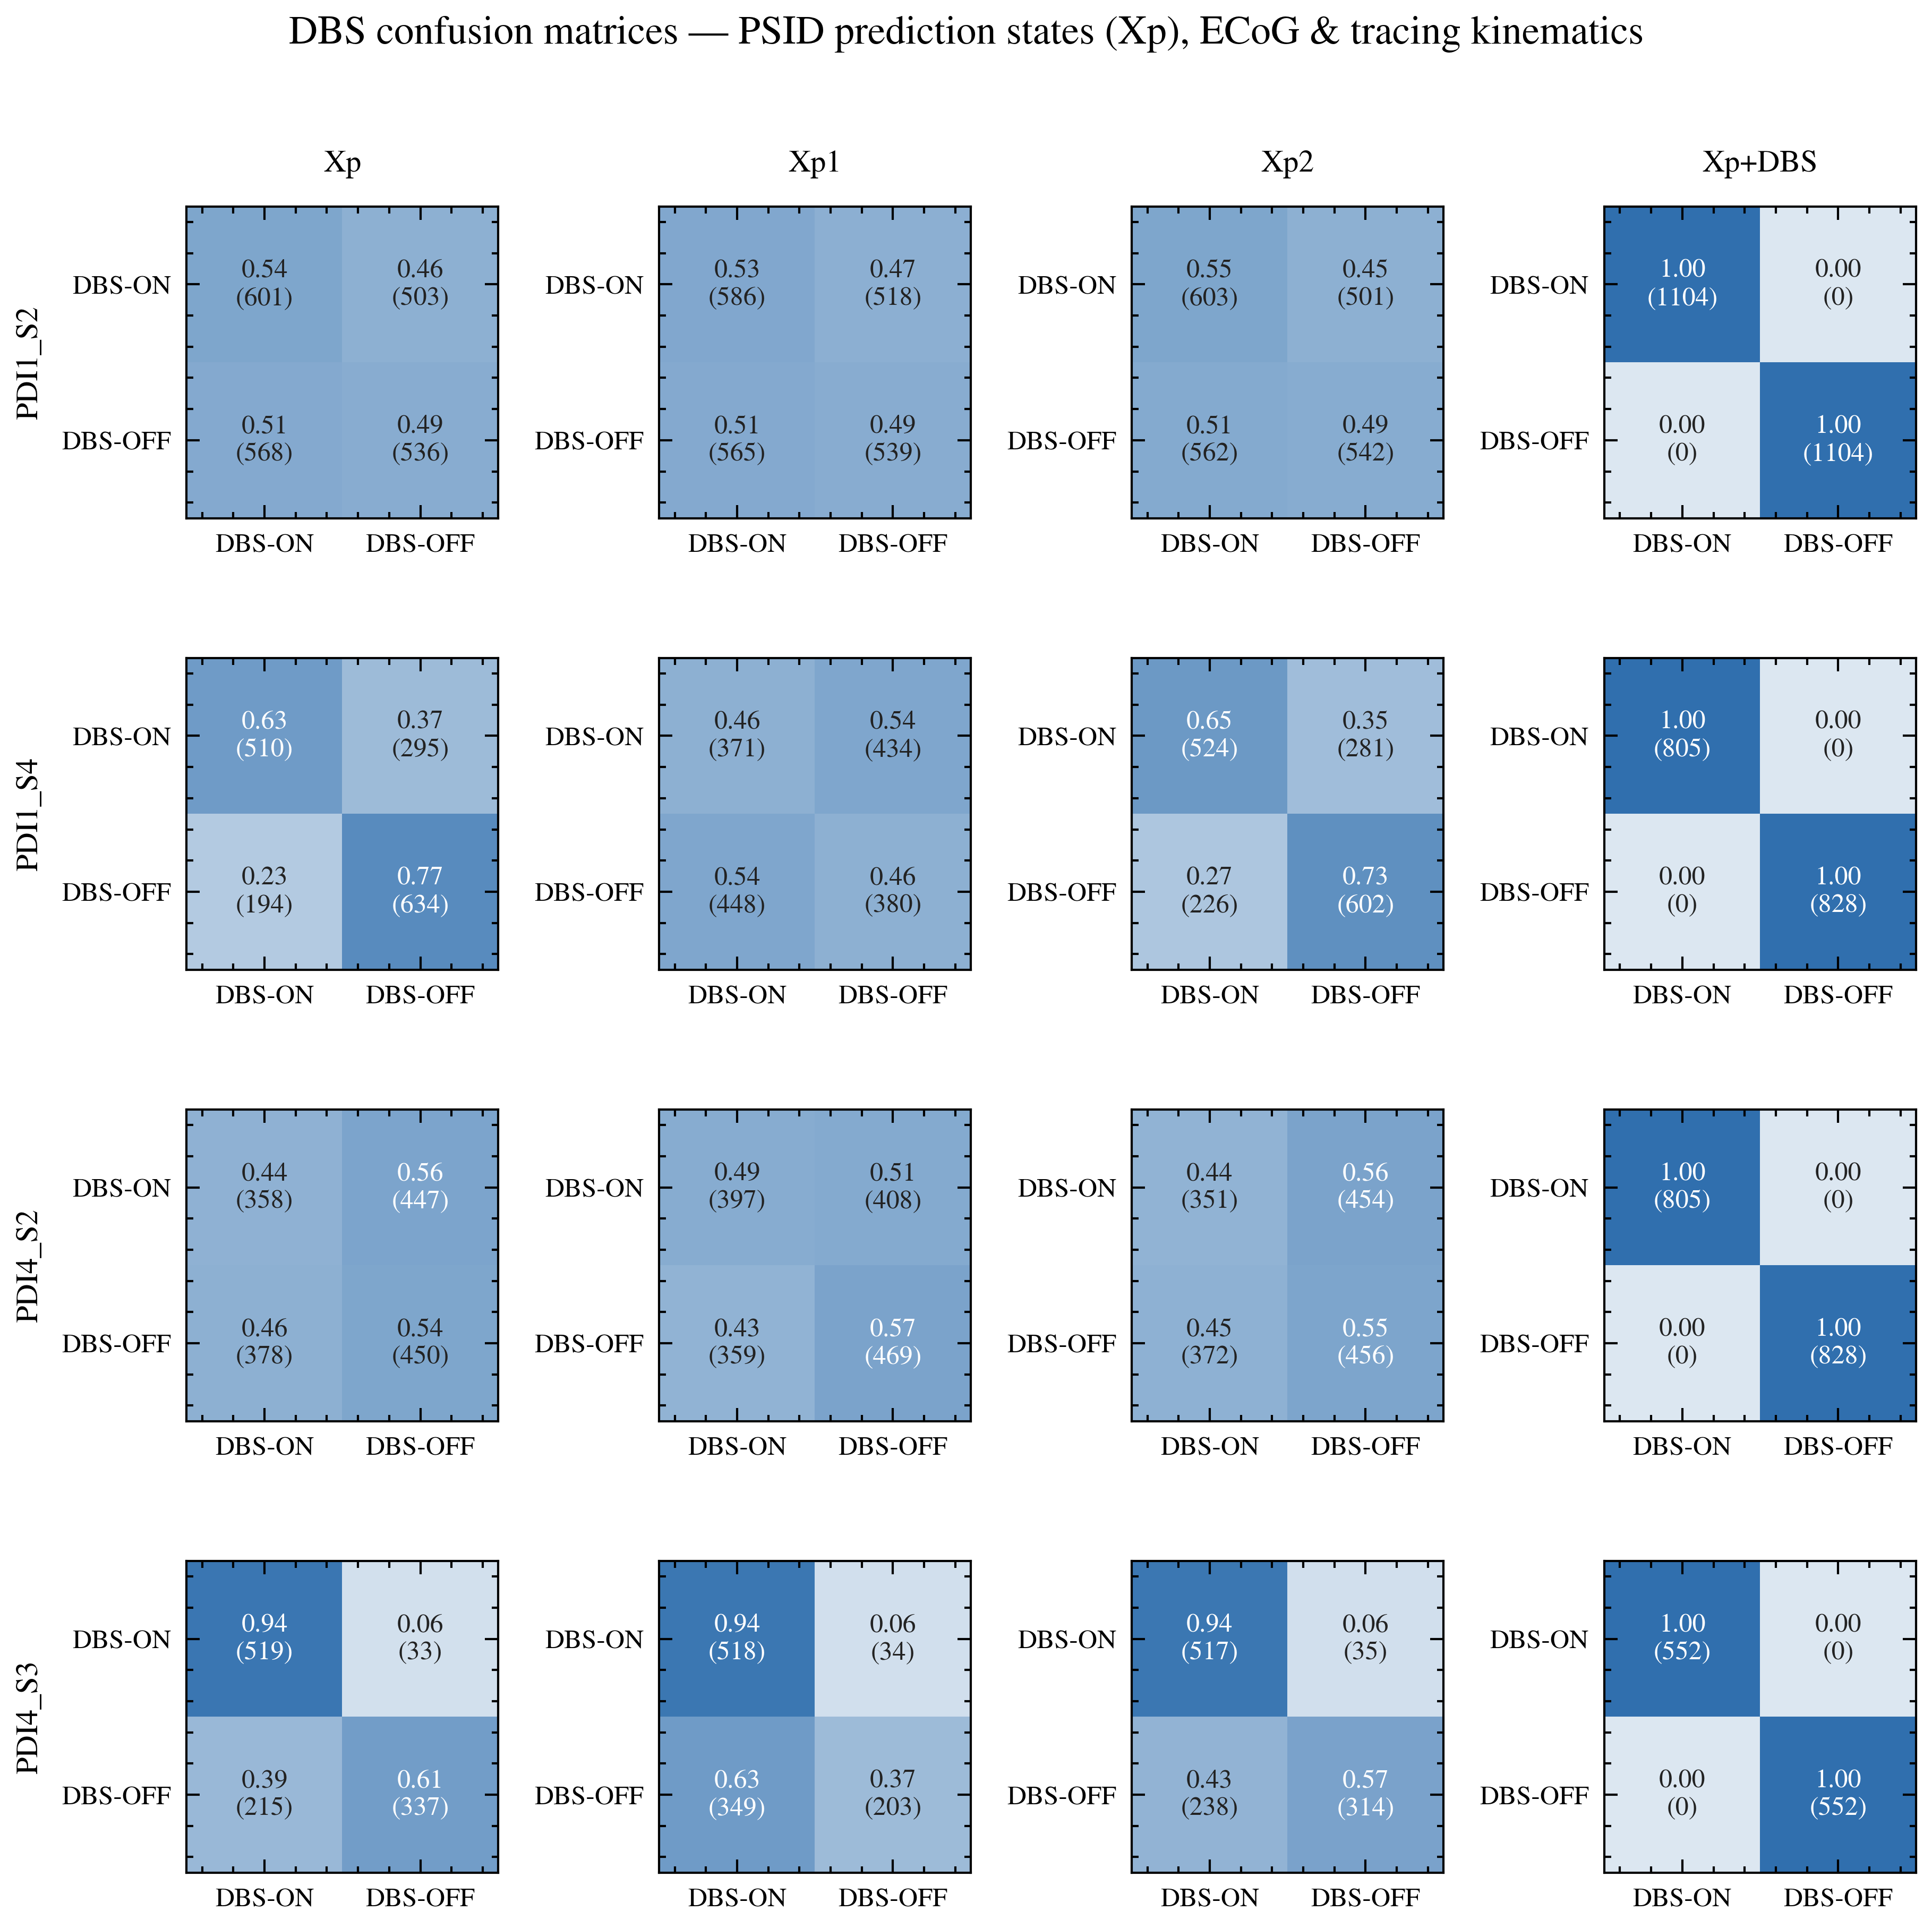

Fig 49a (psid_beh) — DBS confusion matrices: PSID, behavioral.


/tmp/ipykernel_1673195/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


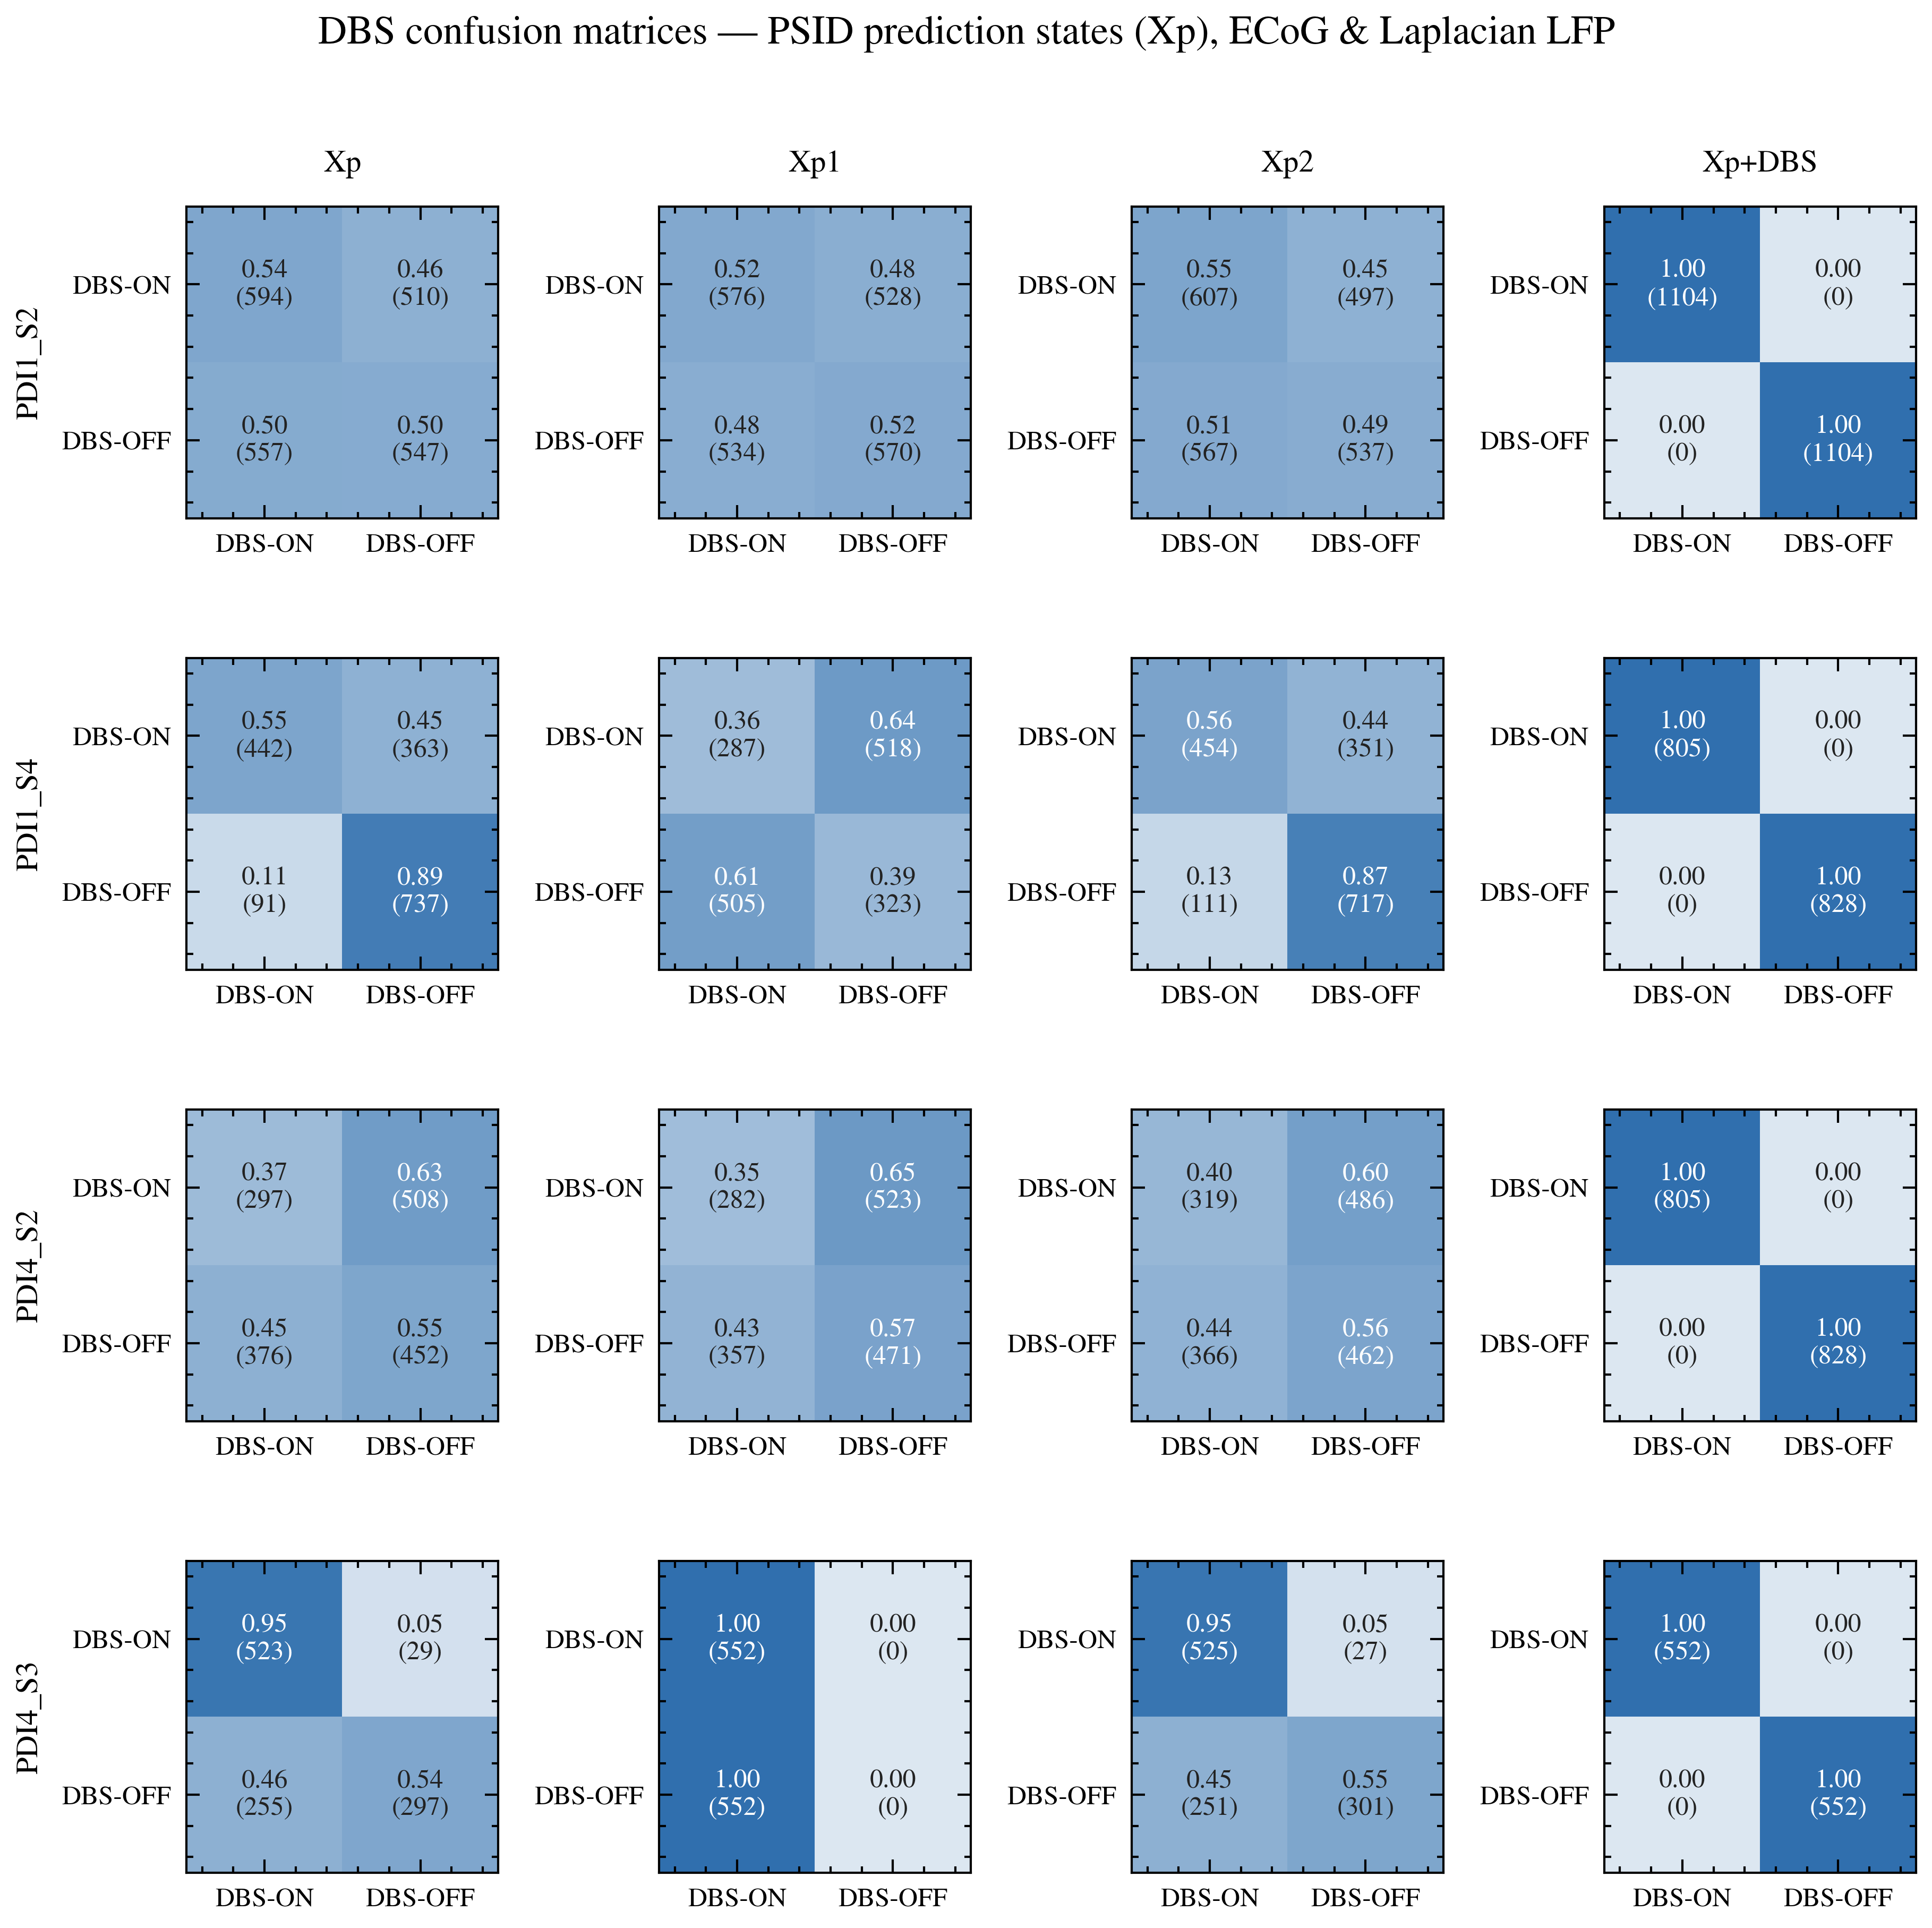

Fig 49a (psid_lap) — DBS confusion matrices: PSID, laplacian.


/tmp/ipykernel_1673195/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


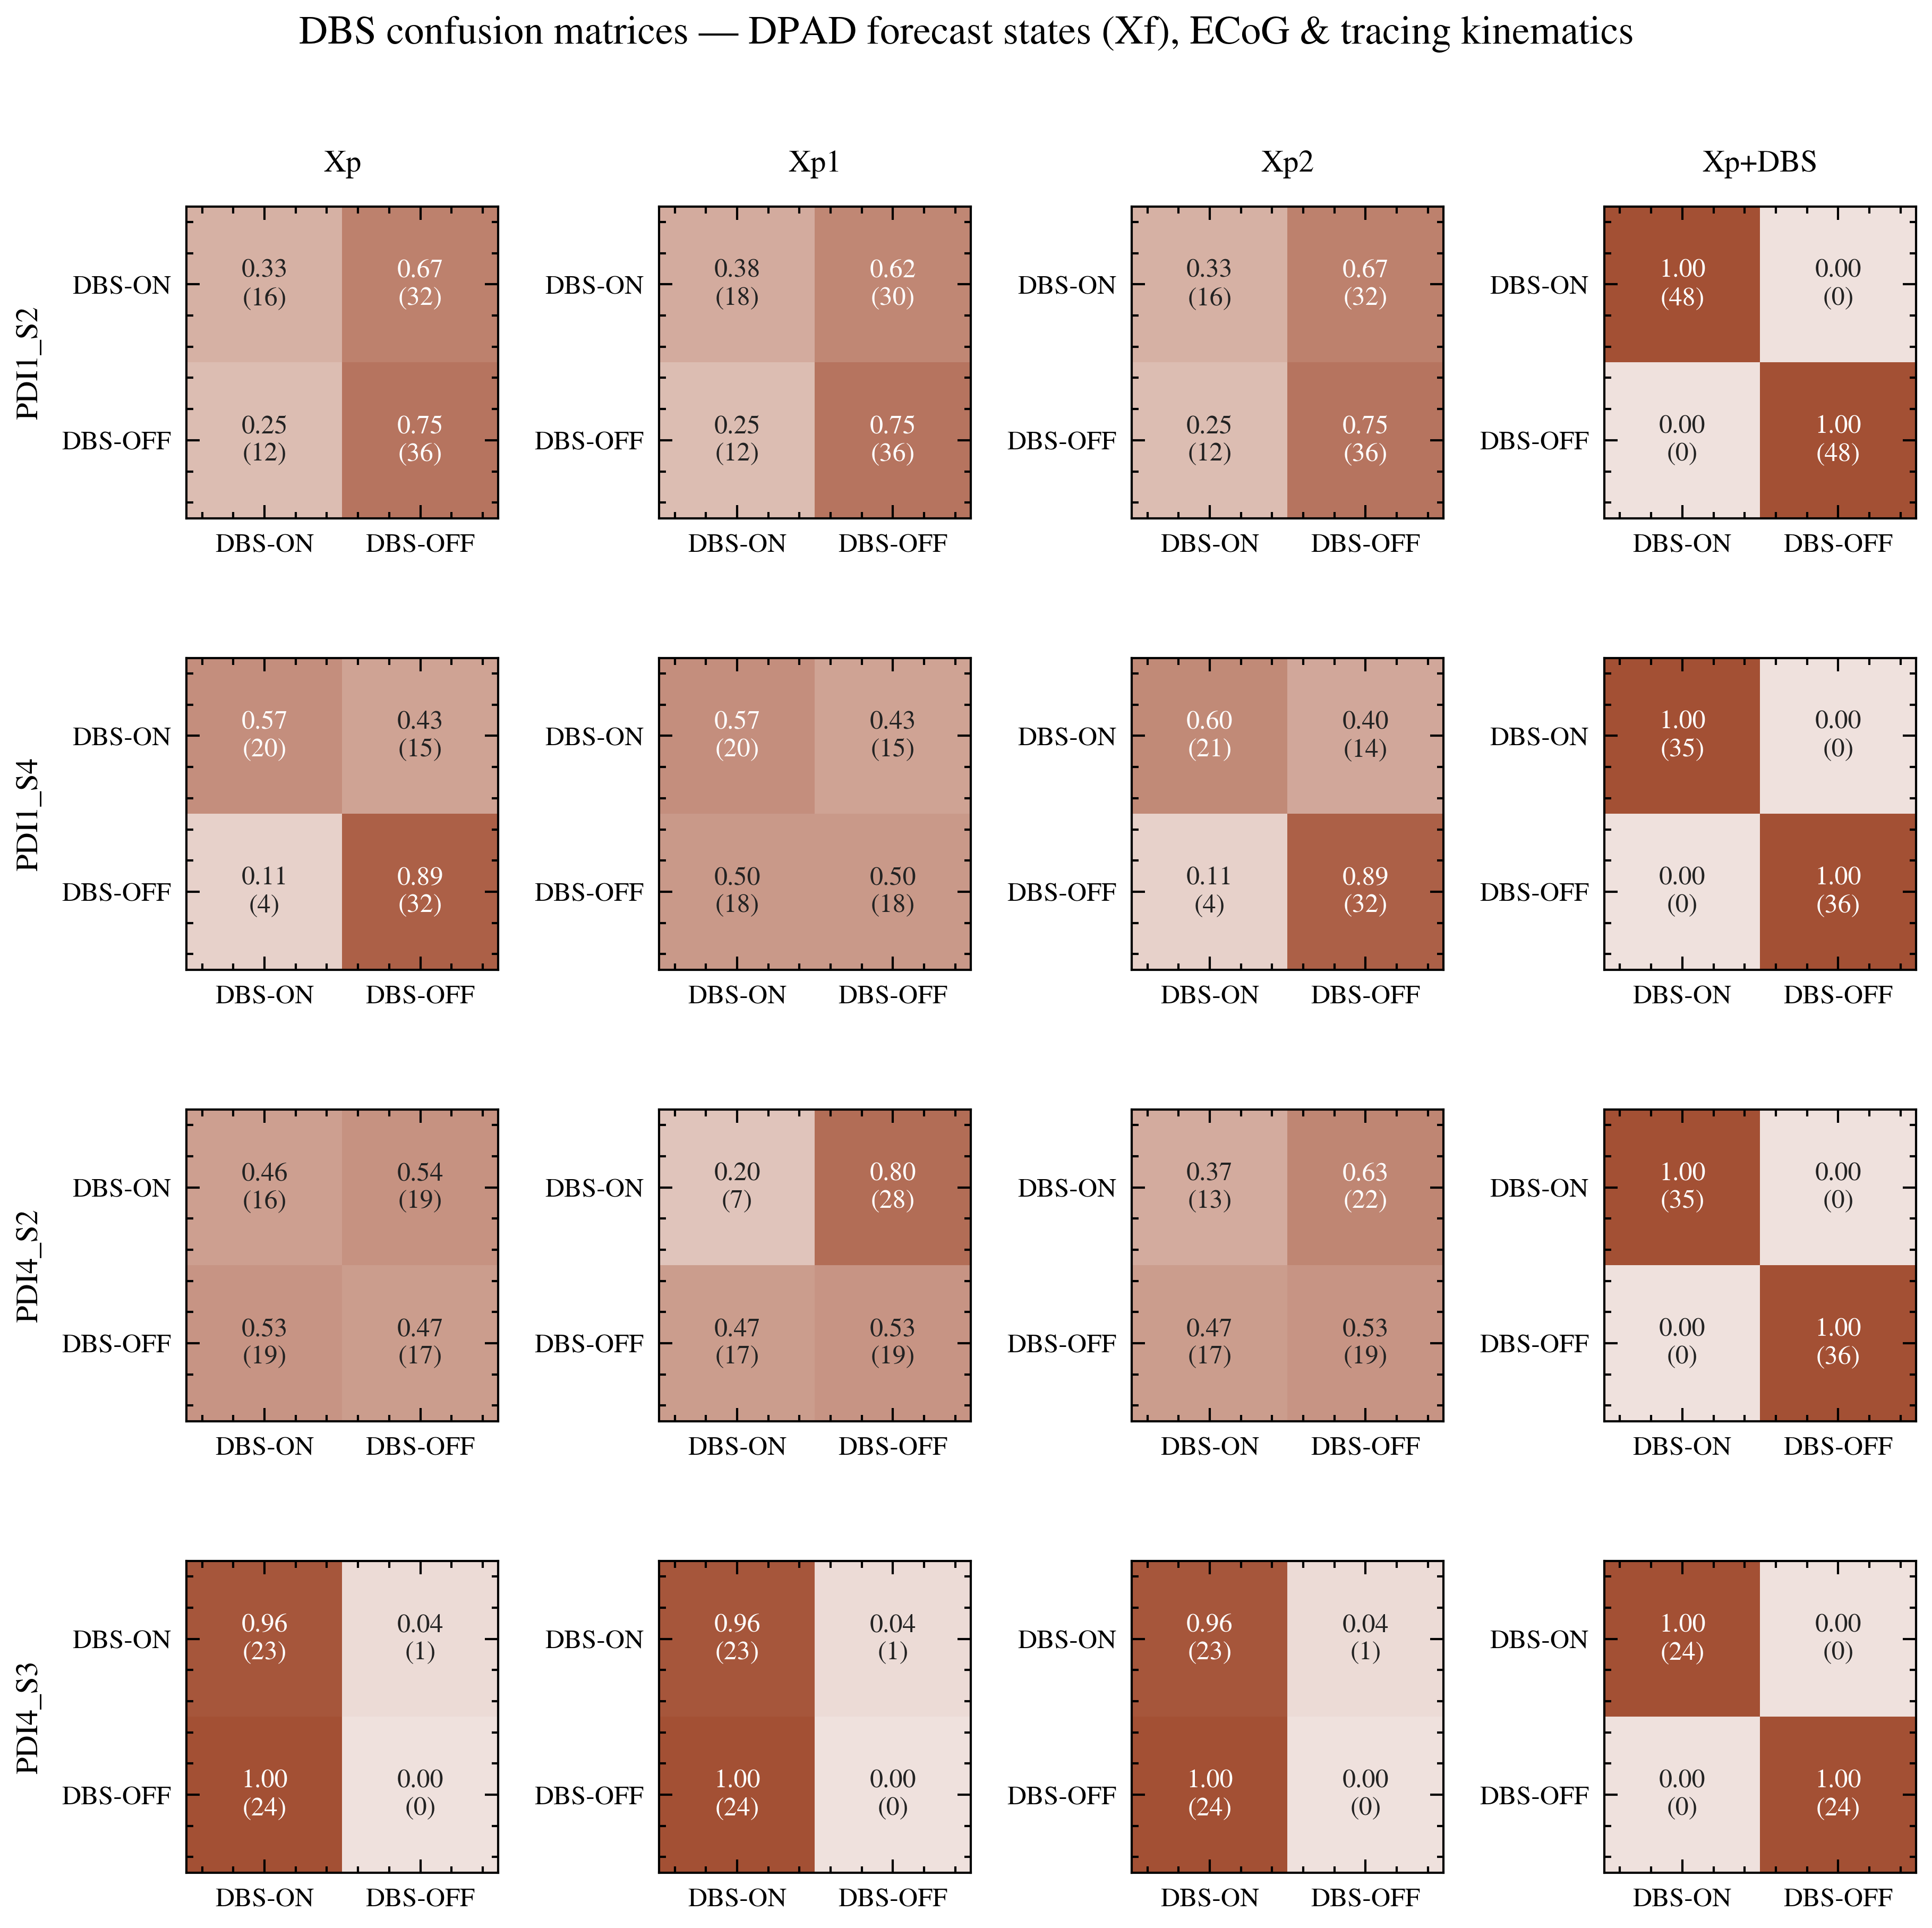

Fig 49a (dpad_beh) — DBS confusion matrices: DPAD, behavioral.


/tmp/ipykernel_1673195/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


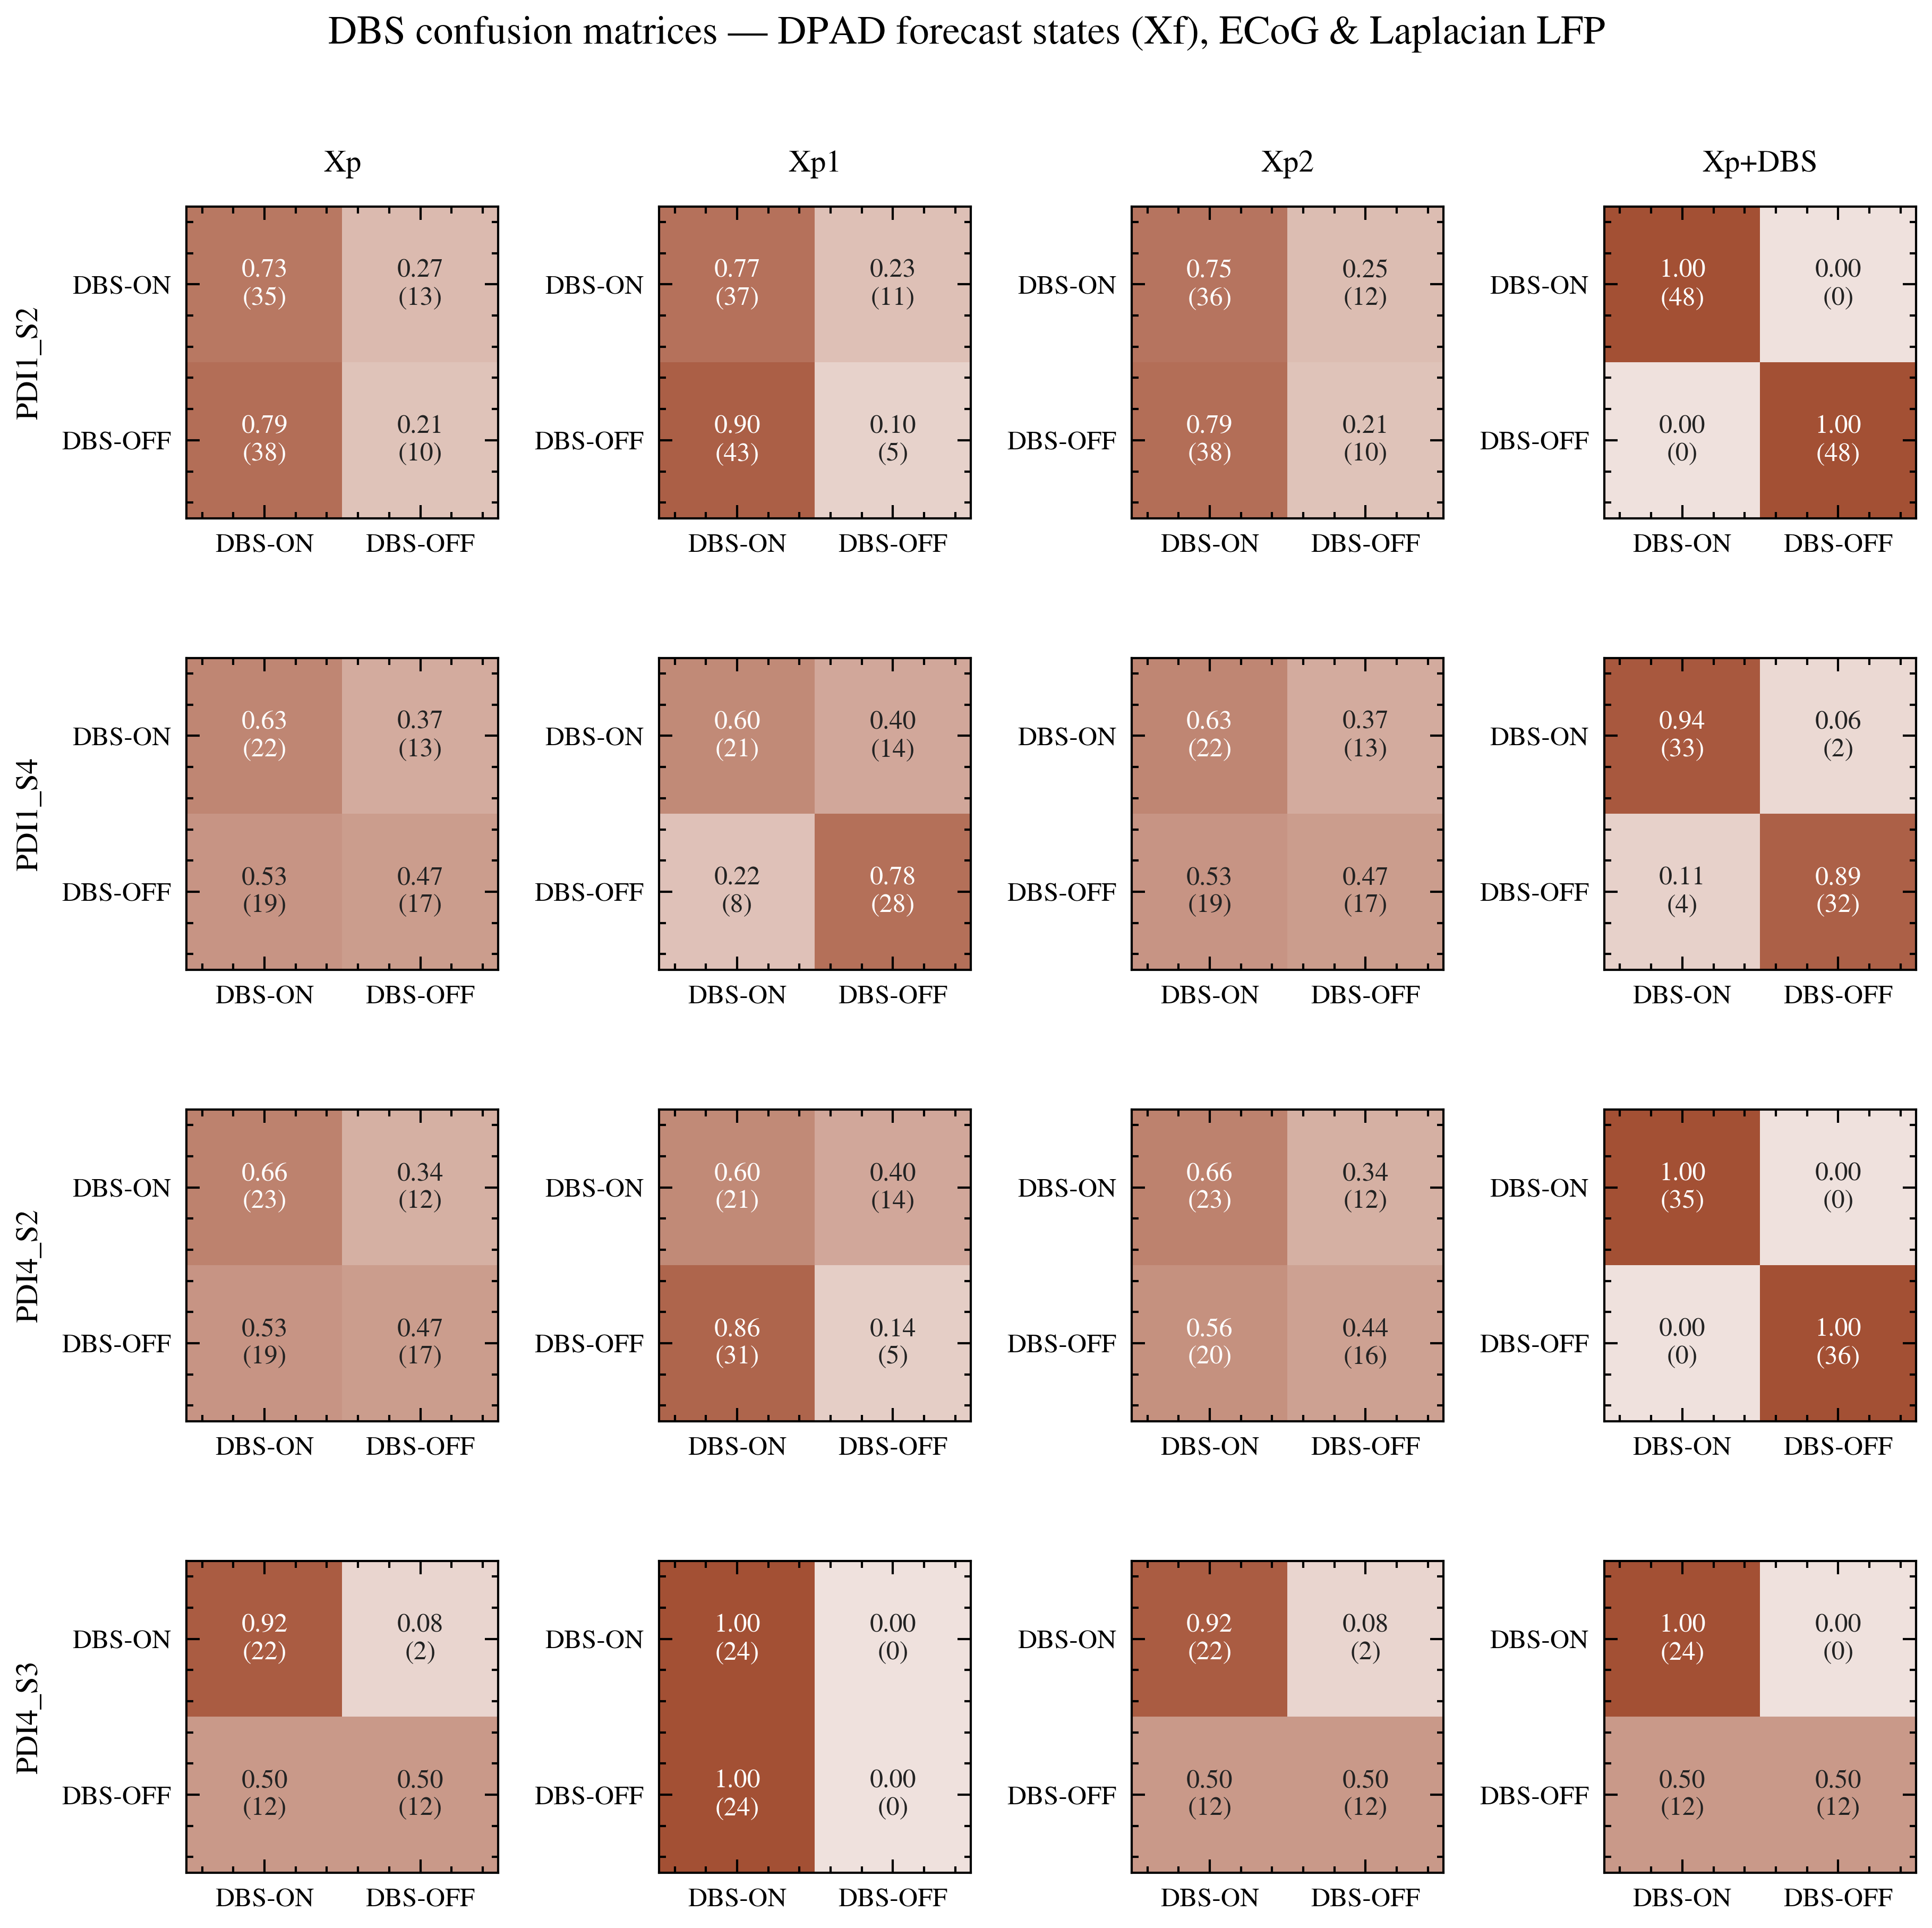

Fig 49a (dpad_lap) — DBS confusion matrices: DPAD, laplacian.


In [21]:
for pipe, mode, suffix in [
    ("psid", "behavioral", "psid_beh"),
    ("psid", "laplacian", "psid_lap"),
    ("dpad", "behavioral", "dpad_beh"),
    ("dpad", "laplacian", "dpad_lap"),
]:
    fig = _confusion_grid(pipe=pipe, mode=mode)
    if fig is not None:
        fname = f"fig_049a_confusion_{suffix}.png"
        fig.savefig(str(OUT / fname))
        plt.show()
        print(f"Fig 49a ({suffix}) — DBS confusion matrices: {pipe.upper()}, {mode}.")
    else:
        print(f"No data: pipe={pipe}, mode={mode}")

## Fig 51: Flipped classification — cross-condition forecast (1×2 dot plot)

Cross-condition forecast classification (mode=forecast, flipped=True). PSID only.

x-axis: feature group (Xp | Xp1 | Xp2). Dots colored by session. Filled dot with black edge = p < 0.05; faded = n.s.

Fixed config (h=5 s past, m=2 s forecast) per (session, feature) from the flipped=True forecast sweep.

**Plotted statistic is `cv_ba`**, as in Fig 49 — `_permutation_pvalue_flipped` tests the cross-validated balanced accuracy, so that is what the markers and the null box share. `ba_at_score` is printed alongside.

**Permutation null:** thin grey box plot of the pooled 500-draw null distribution, drawn beside the observed markers. The flipped null shuffles model-identity labels *within* each block, so it is well sampled (65–409 distinct values) and the boxes render smoothly — unlike Fig 49's block-level null.

**Key finding:** PDI1_S4, PDI4_S2, PDI4_S3 reach p=0.002 (minimum with 500 permutations) for Xp and Xp2 in both experiments. PDI1_S2 is n.s. — the only exception. Cross-condition generalization works for 3 of 4 sessions. Exact tested/gated counts and the per-condition table are printed by the census cell below; quote those, not the plan's.


Cross-model (flipped) forecast classification at fixed h=5 s, m=2 s (PSID):
session          group   cv_ba ba@score       p
PDI1_S2          xp      0.492    0.593     -  
PDI1_S2          xp_1    0.495    0.466     -  
PDI1_S2          xp_2    0.500    0.593     -  
PDI1_S2          xp_with_dbs  1.000    1.000   0.002
PDI1_S2 (lap)    xp      0.523    0.573   0.218
PDI1_S2 (lap)    xp_1    0.505    0.518   0.529
PDI1_S2 (lap)    xp_2    0.523    0.573   0.250
PDI1_S2 (lap)    xp_with_dbs  1.000    1.000   0.002
PDI1_S4          xp      0.662    0.775   0.002
PDI1_S4          xp_1    0.550    0.547   0.068
PDI1_S4          xp_2    0.616    0.756   0.002
PDI1_S4          xp_with_dbs  1.000    1.000   0.002
PDI1_S4 (lap)    xp      0.683    0.683   0.002
PDI1_S4 (lap)    xp_1    0.519    0.642   0.162
PDI1_S4 (lap)    xp_2    0.680    0.666   0.002
PDI1_S4 (lap)    xp_with_dbs  1.000    1.000   0.002
PDI4_S2          xp      0.647    0.770   0.002
PDI4_S2          xp_1    0.709    0.736

/tmp/ipykernel_1673195/2164916732.py:120: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


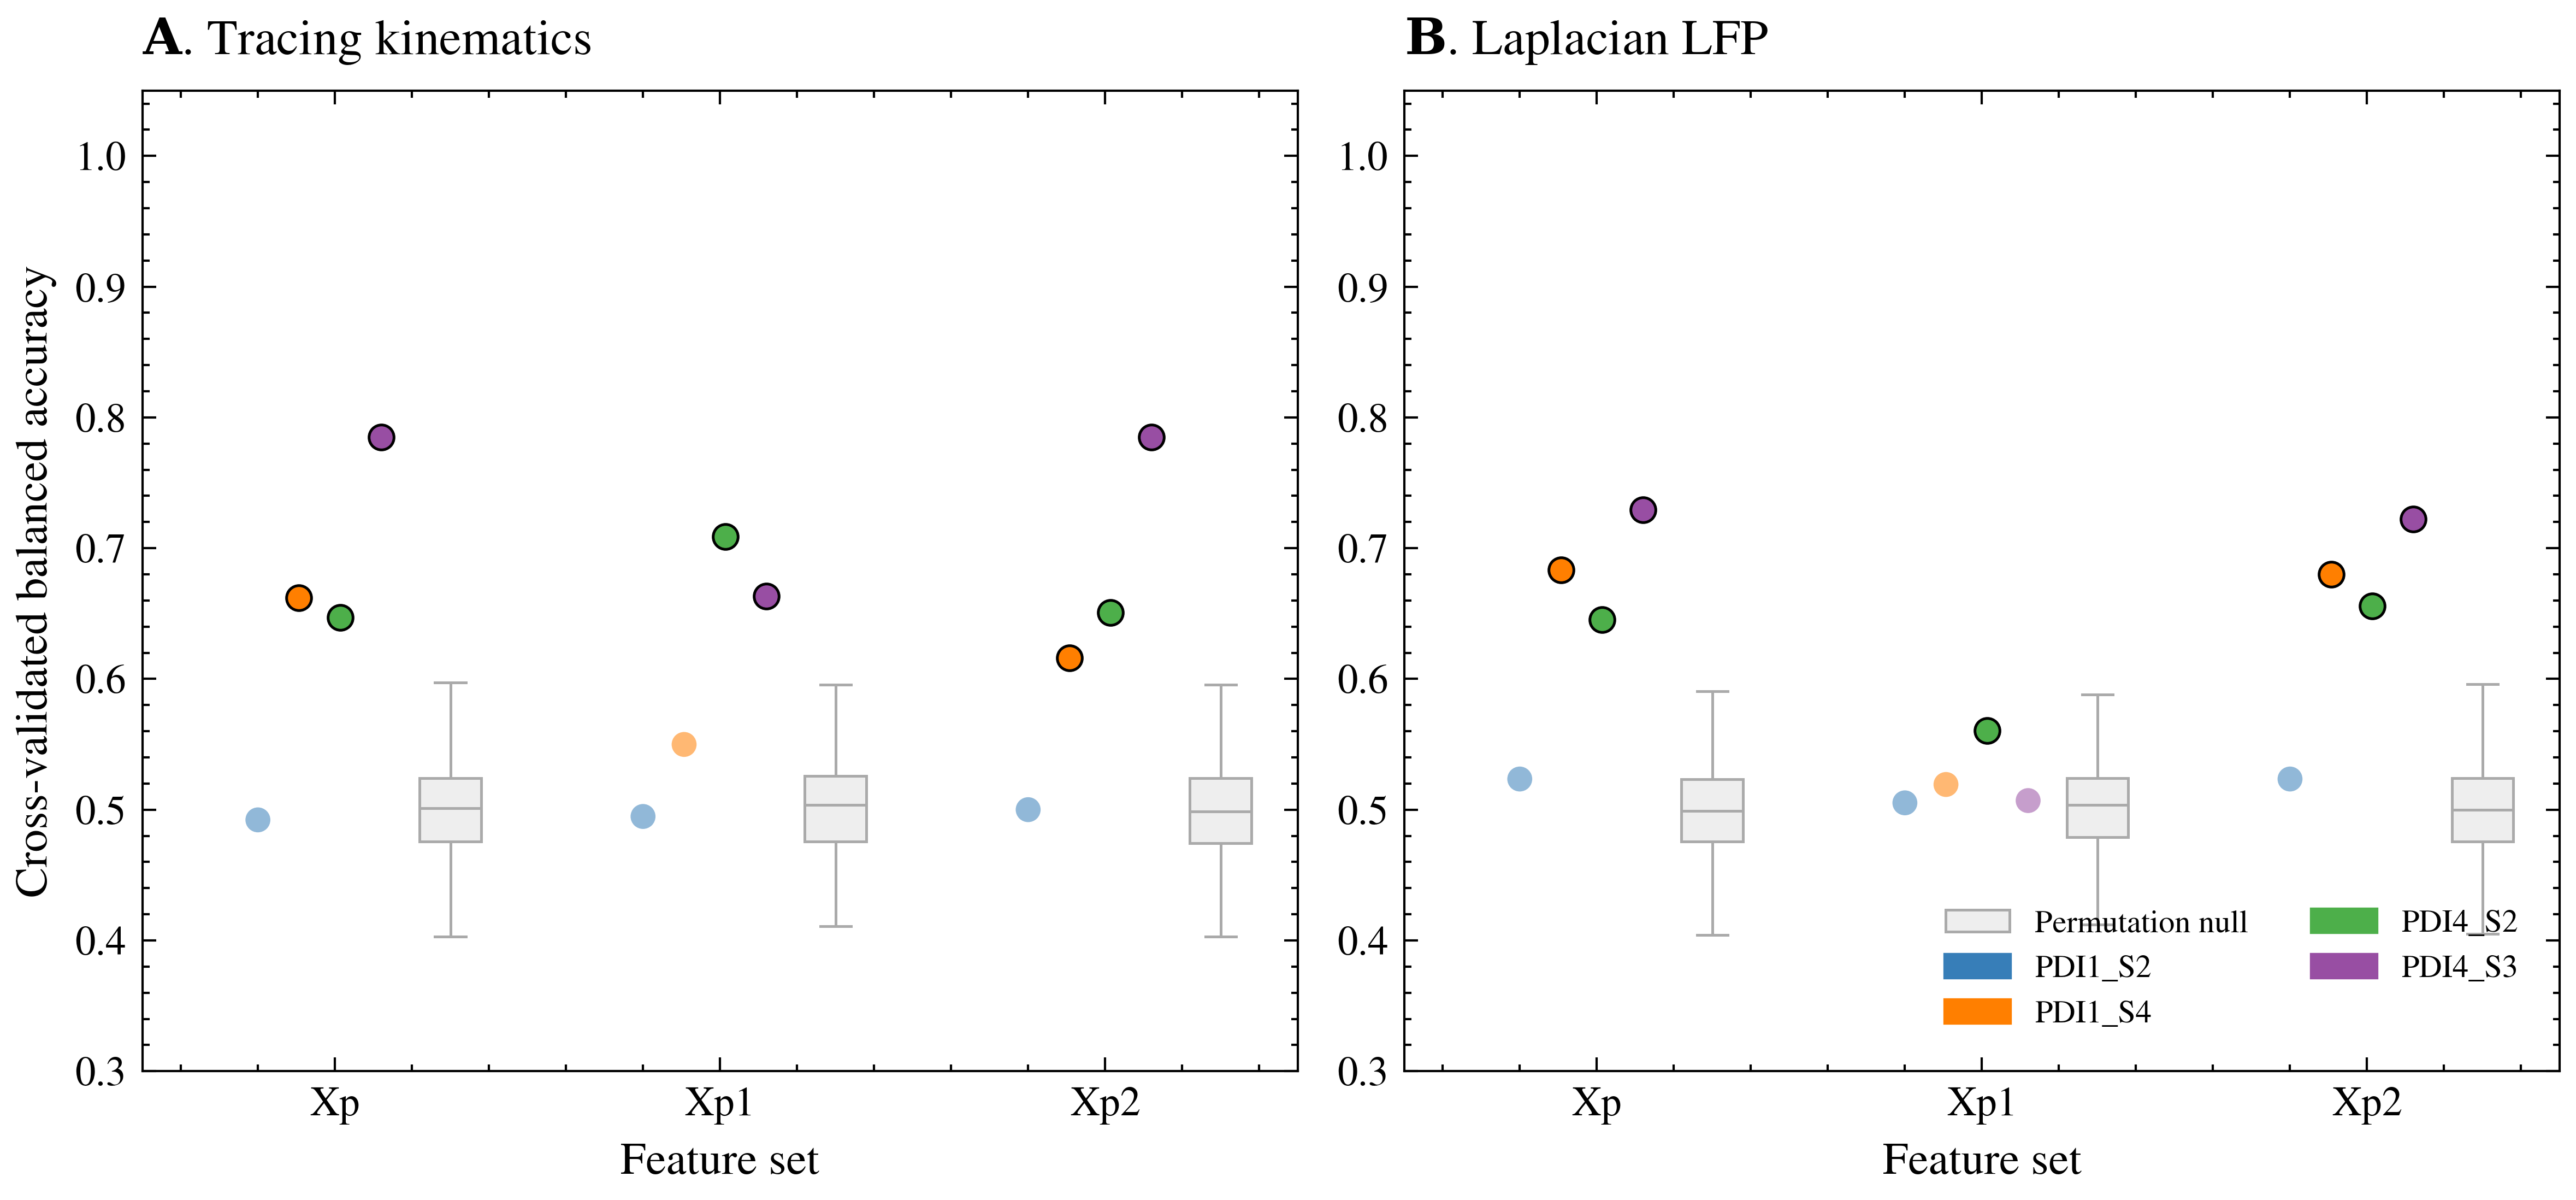

Fig 51 — Cross-condition forecast classification, PSID only (Xp / Xp1 / Xp2). Cross-validated balanced accuracy (cv_ba), the statistic the permutation test tests. 1x2: z-as-behavior (A), z-as-neural (B). Grey box = pooled permutation null (500 draws per tested session, same cv_ba scale). Filled dot = p<0.05; faded = n.s.


In [22]:
def build_flipped_bests_from_parquet() -> Dict[Tuple[str, str], Tuple[float, str, Optional[float], Optional[Tuple], float]]:
    """Flipped=True PSID forecast per (session_key, feature_group) at the reported config.

    Returns (cv_ba, h_m, p_value, perm_scores, ba_at_score). As in the within-model case,
    `cv_ba` is what `_permutation_pvalue_flipped` tests and what each null draw
    reproduces; `ba_at_score` is the transfer score and is never tested.
    """
    if _sweep_df.empty:
        return {}
    df = _sweep_df[
        (_sweep_df["mode"] == "forecast")
        & (_sweep_df["flipped"] == True)
        & (_sweep_df["sub_source"].isin(_FCST_SRC_TO_GROUP.keys()))
        & (_sweep_df["variant"].str.contains("_dbs_both$"))
        & (_sweep_df["pipeline"] == "psid")
        & (_sweep_df["h_seconds"] == _FIXED_H)
        & (_sweep_df["m_test_seconds"] == _FIXED_M)
    ]
    best = df.drop_duplicates(subset=["variant", "sub_source"])
    out: Dict[Tuple[str, str], Tuple[float, str, Optional[float], Optional[Tuple], float]] = {}
    for _, row in best.iterrows():
        exp_type, participant, session, _ = _parse_variant_meta(row["variant"])
        if participant is None:
            continue
        group = _FCST_SRC_TO_GROUP[row["sub_source"]]
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        sess_key = f"{participant}_{sess_label}"
        pval = float(row["p_value"]) if pd.notna(row["p_value"]) else None
        h_m = _score_config(row)
        raw_scores = row.get("perm_scores")
        pscores = (
            tuple(float(v) for v in raw_scores)
            if raw_scores is not None and hasattr(raw_scores, "__len__") and len(raw_scores) > 0
            else None
        )
        out[(sess_key, group)] = (
            float(row["cv_ba"]), h_m, pval, pscores, float(row["ba_at_score"])
        )
    return out


flipped_bests = build_flipped_bests_from_parquet()

print("\nCross-model (flipped) forecast classification at fixed h=5 s, m=2 s (PSID):")
print(f"{'session':16s} {'group':6s} {'cv_ba':>6s} {'ba@score':>8s} {'p':>7s}")
for _k in sorted(flipped_bests):
    _cv, _hm, _pv, _, _bas = flipped_bests[_k]
    _ps = f"{_pv:.3f}" if _pv is not None else "  -  "
    print(f"{_k[0]:16s} {_k[1]:6s} {_cv:6.3f} {_bas:8.3f} {_ps:>7s}")

pooled_flip: Dict[Tuple[str, str, str], List] = {}
for (sess, grp), (cv_ba, hm, pval, pscores, ba_score) in flipped_bests.items():
    exp_mode = _mode_from_session_label(sess)
    pooled_flip.setdefault((grp, "PSID", exp_mode), []).append(
        (sess, cv_ba, pval, pscores, ba_score, hm)
    )

def _rank_flip(e):
    base = e[0].replace(" (lap)", "")
    try:
        return list(SESSIONS).index(base)
    except ValueError:
        return 99

def _slots_flip(n, lo, hi):
    if n <= 0:
        return np.array([])
    if n == 1:
        return np.array([(lo + hi) / 2.0])
    return np.linspace(lo, hi, n)

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.8))

flip_features = [f for f in features if f != "xp_with_dbs"]
for ax, exp_mode, letter, exp_label in zip(
    axes, ["behavioral", "laplacian"], ["A", "B"], ["Tracing kinematics", "Laplacian LFP"]
):
    for fi, feat in enumerate(flip_features):
        entries = sorted(pooled_flip.get((feat, "PSID", exp_mode), []), key=_rank_flip)

        # Pooled permutation null (all 500 draws per tested session, not percentiles).
        all_pscores = []
        for entry in entries:
            if entry[3] is not None:
                all_pscores.extend(entry[3])
        _draw_null_box(ax, fi + 0.30, all_pscores)

        xs = _slots_flip(len(entries), fi - 0.20, fi + 0.12)
        for j, entry in enumerate(entries):
            sess_key, cv_ba, pval = entry[0], entry[1], entry[2]
            if not np.isfinite(cv_ba):
                continue
            sess_color = SESSION_COLORS.get(sess_key.replace(" (lap)", ""), "#888888")
            sig = pval is not None and pval < 0.05
            ax.scatter(
                xs[j], cv_ba, s=30, color=sess_color,
                alpha=1.0 if sig else 0.55,
                edgecolor="black" if sig else "none",
                linewidths=0.6, zorder=3,
            )

    ax.set_ylim(0.3, 1.05)
    ax.set_xticks(np.arange(len(flip_features)))
    ax.set_xticklabels([GROUP_SHORT[f] for f in flip_features])
    ax.set_xlim(-0.5, len(flip_features) - 0.5)
    ax.set_xlabel("Feature set")
    panel_label(ax, letter, exp_label)

axes[0].set_ylabel("Cross-validated balanced accuracy")

legend_handles = [
    Patch(facecolor="#EEEEEE", edgecolor="#AAAAAA", linewidth=0.6, label="Permutation null"),
    Patch(color=SESSION_COLORS["PDI1_S2"], label="PDI1_S2"),
    Patch(color=SESSION_COLORS["PDI1_S4"], label="PDI1_S4"),
    Patch(color=SESSION_COLORS["PDI4_S2"], label="PDI4_S2"),
    Patch(color=SESSION_COLORS["PDI4_S3"], label="PDI4_S3"),
]
axes[1].legend(handles=legend_handles, fontsize=7, loc="lower right", ncol=2)

fig.tight_layout()
fig.savefig(str(OUT / "fig_051_flipped_classification.png"))
plt.show()

print(
    "Fig 51 — Cross-condition forecast classification, PSID only (Xp / Xp1 / Xp2). "
    "Cross-validated balanced accuracy (cv_ba), the statistic the permutation test tests. "
    "1x2: z-as-behavior (A), z-as-neural (B). "
    "Grey box = pooled permutation null (500 draws per tested session, same cv_ba scale). "
    "Filled dot = p<0.05; faded = n.s."
)


## Tested / gated census

Authoritative counts for both permutation families, printed from the full sweep grid.

A **condition** is one independent classifier fit and one permutation test: a unique
`(variant, sub_source, mode, flipped, h_seconds)`. `cv_ba`, `p_value` and `perm_scores` are
computed once per condition and broadcast to every grid row (`sweep.py:293-322`), so
counting *rows* inflates the totals by the size of the `t_cut` / `m_test` grid. Both counts
are printed.

**Gated** = `p_value` is null because `cv_ba > perm_ba_gate = 0.5` failed
(`sweep.py:296`), i.e. the condition was never tested — not tested-and-null.

In [23]:
# Tested / gated census for both permutation families.
#
# A *condition* is one classifier fit and one permutation test: a unique
# (variant, sub_source, mode, flipped, h_seconds). cv_ba / p_value / perm_scores are
# computed once per condition and broadcast to every grid row (sweep.py:313-322), so a
# row count multiplies the totals by the size of the t_cut / m_test grid. Both levels are
# printed: condition-level is the statistically meaningful count, row-level is what an
# ad-hoc parquet query returns.
_COND_KEY = ["variant", "sub_source", "mode", "flipped", "h_seconds"]


def _census(df: pd.DataFrame, label: str) -> Dict[str, int]:
    """Conditions / tested / p<0.05, at both condition and grid-row level."""
    cond = df.drop_duplicates(subset=_COND_KEY)
    out = {
        "conds": len(cond),
        "cond_tested": int(cond["p_value"].notna().sum()),
        "cond_sig": int((cond["p_value"] < 0.05).sum()),
        "rows": len(df),
        "row_tested": int(df["p_value"].notna().sum()),
        "row_sig": int((df["p_value"] < 0.05).sum()),
    }
    out["cond_gated"] = out["conds"] - out["cond_tested"]
    out["row_gated"] = out["rows"] - out["row_tested"]
    print(
        f"{label:44s} {out['conds']:5d} {out['cond_tested']:6d} {out['cond_gated']:5d} "
        f"{out['cond_sig']:5d} | {out['rows']:6d} {out['row_tested']:6d} "
        f"{out['row_gated']:5d} {out['row_sig']:5d}"
    )
    return out


_latent = _sweep_df[_sweep_df["sub_source"].isin(_LATENT_SRC)]
_within = _latent[_latent["flipped"] == False]
_flip = _latent[_latent["flipped"] == True]
_wb = _within[_within["variant"].str.contains("_dbs_both$")]
_fb = _flip[_flip["variant"].str.contains("_dbs_both$")]

print("Latent-only conditions (Xp/Xp1/Xp2/Xf/Xf1/Xf2; the Xp+DBS control is excluded).")
print("'tested' = cleared the cv_ba > 0.5 gate. 'gated' = never tested, not tested-and-null.")
print(
    f"{'family / scope':44s} {'conds':>5s} {'tstd':>6s} {'gated':>5s} {'p<.05':>5s} | "
    f"{'rows':>6s} {'tstd':>6s} {'gated':>5s} {'p<.05':>5s}"
)

_census(_within, "within-model, all dbs states, all modes")
_census(_wb, "within-model, _dbs_both, all modes")
_census(_wb[_wb["mode"] == "predictions"], "within-model, _dbs_both, predictions")
_w_fcst = _census(_wb[_wb["mode"] == "forecast"], "within-model, _dbs_both, forecast (all h)")
_census(_wb[(_wb["mode"] == "forecast") & (_wb["h_seconds"] == _FIXED_H)],
        "within-model, _dbs_both, forecast h=5 (plotted)")

print()
_census(_flip, "cross-condition, all dbs states, all h")
_f_all = _census(_fb, "cross-condition, _dbs_both, all h")
_f_plot = _census(_fb[_fb["h_seconds"] == _FIXED_H],
                  "cross-condition, _dbs_both, h=5 (Fig 51)")

# NOTE on provenance. Earlier ad-hoc parquet queries in this session reported
# 385/438 tested and 4/342 significant for these scopes. Those were computed before the
# `_load_sweep_df` recency fix (see cell 6): six PSID variants have two sweep files, a
# June 14 and a June 15 re-run, carrying the SAME stale `run_ts`, and the old sort could
# not order them, so rows from the incomplete June 14 file survived the dedupe with NaN
# `p_value`. The counts printed above are the corrected ones and supersede those numbers.
print(
    "\nProvenance: counts above use file-stamp recency (cell 6). Pre-fix ad-hoc queries "
    "reported 385/438 tested and 4/342 significant; those mixed rows from a superseded "
    "June 14 sweep file and are wrong."
)

# Which within-model conditions are significant, and at which h — the h that matters is
# not necessarily the plotted h=5.
_w_sig = _wb[_wb["p_value"] < 0.05].drop_duplicates(subset=_COND_KEY)
print("\nWithin-model conditions at p<0.05:")
for _, _row in _w_sig.iterrows():
    _exp_type, _participant, _session, _ = _parse_variant_meta(_row["variant"])
    _h = _row["h_seconds"]
    _htxt = "-" if pd.isna(_h) else f"{_h:g}"
    _tgt = "LFP" if _exp_type == "laplacian" else "kin"
    print(
        f"  {_row['pipeline']:5s} {_row['mode']:11s} {_tgt:4s} "
        f"{_participant}_{_session:4s} {_row['sub_source']:6s} h={_htxt:>3s} "
        f"cv_ba={float(_row['cv_ba']):.3f} p={float(_row['p_value']):.3f}"
    )
if not len(_w_sig):
    print("  none")

# cv_ba span among significant cross-condition rows — quote this, not ba_at_score.
_f_sig = _fb[_fb["p_value"] < 0.05]
if len(_f_sig):
    print(
        f"\nCross-condition rows at p<0.05: cv_ba spans {_f_sig['cv_ba'].min():.3f} to "
        f"{_f_sig['cv_ba'].max():.3f} (ba_at_score spans "
        f"{_f_sig['ba_at_score'].min():.3f} to {_f_sig['ba_at_score'].max():.3f})."
    )

# The plan quotes 393/720 within-model and 18/24 for the plotted flipped set.
print(
    f"\nPlotted flipped set (Fig 51): {_f_plot['cond_tested']} of {_f_plot['conds']} "
    f"tested, {_f_plot['cond_gated']} gated, {_f_plot['cond_sig']} at p<0.05."
)
print("RESULTS_FIX_PLAN.md claims 18 of 24 tested; that predates the recency fix.")
if (_f_plot["conds"], _f_plot["cond_tested"]) != (24, 18):
    print(
        f"  MISMATCH — measured ({_f_plot['cond_tested']} of {_f_plot['conds']}) "
        "disagrees with the plan (18 of 24). The thesis quotes the plan; fix before citing."
    )

# Per-condition breakdown for the plotted flipped set — the gated ones are exactly the
# conditions the prose must not describe as null.
print("\nPlotted flipped set, per condition:")
_flip_rows = []
for _, _row in _fb[_fb["h_seconds"] == _FIXED_H].drop_duplicates(subset=_COND_KEY).iterrows():
    _exp_type, _participant, _session, _ = _parse_variant_meta(_row["variant"])
    if _participant is None:
        continue
    _flip_rows.append((
        "LFP" if _exp_type == "laplacian" else "kin",
        f"{_participant}_{_session}",
        _FCST_SRC_TO_GROUP[_row["sub_source"]],
        float(_row["cv_ba"]),
        float(_row["p_value"]) if pd.notna(_row["p_value"]) else None,
    ))
_flip_rows.sort()
print(f"{'target':6s} {'session':10s} {'feature':8s} {'cv_ba':>6s} {'p':>8s}")
for _tgt, _sess, _grp, _cv, _pv in _flip_rows:
    print(f"{_tgt:6s} {_sess:10s} {_grp:8s} {_cv:6.3f} "
          f"{(f'{_pv:.3f}' if _pv is not None else 'gated'):>8s}")


# --- Benjamini-Hochberg within each permutation family -----------------------------
# One q per *condition* (not per grid row), so the family size is the tested-condition
# count printed above. Both families are corrected separately: they are different tests
# with different exchangeable sets and different floors.
from statsmodels.stats.multitest import multipletests


def _bh(df: pd.DataFrame, label: str) -> None:
    cond = df.drop_duplicates(subset=_COND_KEY)
    tested = cond[cond["p_value"].notna()].copy()
    if tested.empty:
        print(f"{label}: nothing tested")
        return
    rej, q, _, _ = multipletests(
        tested["p_value"].values, alpha=0.05, method="fdr_bh"
    )
    tested["q"] = q
    print(
        f"{label}: {len(tested)} tested, min raw p = {tested['p_value'].min():.4f}, "
        f"min q = {tested['q'].min():.4f}, {int(rej.sum())} reject at q < 0.05"
    )
    for _, r in tested.nsmallest(4, "p_value").iterrows():
        print(
            f"    {r['variant'].replace('psid_', '').replace('dpad_', ''):46s} "
            f"{r['sub_source']:5s} {r['mode']:11s} h={r['h_seconds']} "
            f"cv_ba={r['cv_ba']:.3f} p={r['p_value']:.4f} q={r['q']:.4f}"
        )


print("\nBenjamini-Hochberg, per family (condition-level):")
_bh(_within, "within-model, all DBS states, all h")
_bh(_flip, "cross-condition, all DBS states, all h")
_bh(_fb[_fb["h_seconds"] == _FIXED_H], "cross-condition, _dbs_both, h=5 (Fig 51 family)")


Latent-only conditions (Xp/Xp1/Xp2/Xf/Xf1/Xf2; the Xp+DBS control is excluded).
'tested' = cleared the cv_ba > 0.5 gate. 'gated' = never tested, not tested-and-null.
family / scope                               conds   tstd gated p<.05 |   rows   tstd gated p<.05
within-model, all dbs states, all modes        600    415   185     6 |   2760   1981   779    36
within-model, _dbs_both, all modes             216    127    89     1 |    936    565   371    10
within-model, _dbs_both, predictions            24     16     8     1 |    240    160    80    10
within-model, _dbs_both, forecast (all h)      192    111    81     0 |    696    405   291     0
within-model, _dbs_both, forecast h=5 (plotted)    48     27    21     0 |    120     69    51     0

cross-condition, all dbs states, all h         504    432    72   359 |   2016   1728   288  1436
cross-condition, _dbs_both, all h              168    144    24   119 |    672    576    96   476
cross-condition, _dbs_both, h=5 (Fig 51)      